# Оптимизация производственных расходов
__[Александр Бинько](https://t.me/ABin_98)__

# ➢ Описание проекта  
_Металлургический комбинат оптимизирует производственные затраты.  
Существует необходимость снизить потребление электроэнергии на этапе обработки  
стали. Для этого необходимо предсказывать температуру сплава в ковше с требуемой  
технологами точностью._

# ➢ Требования  
> * Загрузить и валидировать данные, полученные от комбината 
>
> 
> * Провести этапы **EDA** и **Feature-selection**
> 
> 
> * Обучить модели для имитации технологического процесса
> 
> 
> * Выбрать лучшую модель из семейства, проверить качество на тестовом наборе
> 
> 
> * Описать ход исследования и дать рекомендации заказчику


# ➢ Полученные данные  
_Для выполнения исследовательской работы было получено 7 файлов, в формате  
**.csv-таблиц.** Общий объём набора 2.08МБ._


### Стек проекта:
**python** 3.12 | **pandas** 2.2.2  
**seaborn** 0.13.2 | **numpy** 1.26.4

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import shap
import warnings
from matplotlib import pyplot as plt
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

warnings.filterwarnings('ignore')

# Ⅰ Шаг. Загрузка данных

In [2]:
def check_prev(df):
    summary = pd.DataFrame({
        'Имя': df.columns,
        'Тип': df.dtypes,
        'Количество записей': len(df),
        'Уникальные записи': df.nunique(),
        'Пропущенных значений': df.isnull().mean() * 100
    })
    return summary.reset_index(drop=True)

## ➢ Данные об электродах
Описание данных:
>**key** — номер партии  
> 
>**Начало нагрева дугой** — время начала нагрева  
>
>**Конец нагрева дугой** — время окончания нагрева  
>
>**Активная мощность** — значение активной мощности  
>
>**Реактивная мощность** — значение реактивной мощности  

In [3]:
arc_df = pd.read_csv('data_arc_new.csv')
check_prev(arc_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,14876,3214,0.0
1,Начало нагрева дугой,object,14876,14876,0.0
2,Конец нагрева дугой,object,14876,14876,0.0
3,Активная мощность,float64,14876,13846,0.0
4,Реактивная мощность,float64,14876,14707,0.0


**Промежуточный вывод:**
>_Данные получены в полном виде, пропущенные значения отсутствуют.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что индексная переменная имеет всего **3214** уникальных значений,  
строки с одинаковыми значениями являются указателями на параметры различных  
итераций обработки одного заказа._

## ➢ Данные о подаче сыпучих материалов (объём)  
Описание данных:  
>**key** — номер партии  
>  
>**Bulk 1 … Bulk 15** — объём подаваемого материала  


In [4]:
bulk_df = pd.read_csv('data_bulk_new.csv')
check_prev(bulk_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,3129,3129,0.000000
1,Bulk 1,float64,3129,47,91.946309
2,Bulk 2,float64,3129,15,99.296900
3,Bulk 3,float64,3129,278,58.517098
4,Bulk 4,float64,3129,206,67.593480
5,Bulk 5,float64,3129,55,97.539150
6,Bulk 6,float64,3129,205,81.591563
7,Bulk 7,float64,3129,25,99.201023
8,Bulk 8,float64,3129,1,99.968041
9,Bulk 9,float64,3129,10,99.392777


**Промежуточный вывод:**  
>_Данные получены в полном виде.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что значительная часть колонок содержит существенное количество  
Null-значений. На данном этапе исследования определить природу появления этих  
пропусков не представляется возможным._  

## ➢ Данные о подаче сыпучих материалов (время)  
Описание данных:  
>**key** — номер партии  
>  
>**Bulk 1 … Bulk 15** — время подачи материала  


In [5]:
bulk_time_df = pd.read_csv('data_bulk_time_new.csv')
check_prev(bulk_time_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,3129,3129,0.000000
1,Bulk 1,object,3129,252,91.946309
2,Bulk 2,object,3129,22,99.296900
3,Bulk 3,object,3129,1298,58.517098
4,Bulk 4,object,3129,1014,67.593480
5,Bulk 5,object,3129,77,97.539150
6,Bulk 6,object,3129,576,81.591563
7,Bulk 7,object,3129,25,99.201023
8,Bulk 8,object,3129,1,99.968041
9,Bulk 9,object,3129,19,99.392777


**Промежуточный вывод:**  
>_Данные получены в полном виде.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что значительная часть колонок содержит существенное количество  
Null-значений. На данном этапе исследования определить природу появления этих  
пропусков не представляется возможным._  

## ➢ Данные о продувке сплава газом  
Описание данных:  
>**key** — номер партии  
>  
>**Газ 1** — объём подаваемого газа  


In [6]:
gas_df = pd.read_csv('data_gas_new.csv')
check_prev(gas_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,3239,3239,0.0
1,Газ 1,float64,3239,3239,0.0


**Промежуточный вывод:**  
>_Данные получены в полном виде, пропущенные значения отсутствуют.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что количество записей существенно ниже, чем в ранее  
исследованных таблицах._  

## ➢ Результаты измерения температуры  
Описание данных:  
>**key** — номер партии  
>  
>**Время замера** — время замера  
>  
>**Температура** — значение температуры  


In [7]:
temp_df = pd.read_csv('data_temp_new.csv')
check_prev(temp_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,18092,3216,0.000000
1,Время замера,object,18092,18092,0.000000
2,Температура,float64,18092,172,18.942074


**Промежуточный вывод:**  
>_Данные получены в полном виде.  
Почти пятая часть наблюдений в столбце с температурой содержит пропуски, что  
может свидетельствовать о неисправности оборудования или особенностях процесса замера.  
Имена колонок информативны и не содержат ошибок._  

## ➢ Данные о проволочных материалах (объём)  
Описание данных:  
>**key** — номер партии  
>  
>**Wire 1 … Wire 9** — объём подаваемых проволочных материалов  


In [8]:
wire_df = pd.read_csv('data_wire_new.csv')
check_prev(wire_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,3081,3081,0.000000
1,Wire 1,float64,3081,2251,0.843882
2,Wire 2,float64,3081,713,64.978903
3,Wire 3,float64,3081,56,97.955209
4,Wire 4,float64,3081,14,99.545602
5,Wire 5,float64,3081,1,99.967543
6,Wire 6,float64,3081,69,97.630639
7,Wire 7,float64,3081,10,99.642973
8,Wire 8,float64,3081,13,99.383317
9,Wire 9,float64,3081,25,99.058747


**Промежуточный вывод:**  
>_Данные получены в полном виде.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что значительная часть колонок содержит существенное количество  
Null-значений. На данном этапе исследования определить природу появления этих  
пропусков не представляется возможным._  

## ➢ Данные о проволочных материалах (время)  
Описание данных:  
>**key** — номер партии  
>  
>**Wire 1 … Wire 9** — время подачи проволочных материалов  


In [9]:
wire_time_df = pd.read_csv('data_wire_time_new.csv')
check_prev(wire_time_df)

,Имя,Тип,Количество записей,Уникальные записи,Пропущенных значений
0,key,int64,3081,3081,0.000000
1,Wire 1,object,3081,3055,0.843882
2,Wire 2,object,3081,1079,64.978903
3,Wire 3,object,3081,63,97.955209
4,Wire 4,object,3081,14,99.545602
5,Wire 5,object,3081,1,99.967543
6,Wire 6,object,3081,73,97.630639
7,Wire 7,object,3081,11,99.642973
8,Wire 8,object,3081,19,99.383317
9,Wire 9,object,3081,29,99.058747


**Промежуточный вывод:**  
>_Данные получены в полном виде.  
Имена колонок информативны и не содержат ошибок.  
Примечательно, что значительная часть колонок содержит существенное количество  
Null-значений. На данном этапе исследования определить природу появления этих  
пропусков не представляется возможным._  

## Вывод шага Ⅰ:  
> Данные, содержащиеся в предоставленных таблицах не противоречат заявленному  
заказчиком описанию. Все колонки названы корректными и информативными именами.  
Множество пропусков может быть объяснено, как несовершенством системы сбора,  
так и спецификой предметной области исследования, точнее судить  
о доле утерянной информации помогут дополнительные исследования.  
Некоторые из типов данных нуждаются в преобразовании, это снизит  
общие затраты памяти и повысит скорость работы алгоритмов машинного обучения.  

# Ⅱ Шаг. Исследовательский анализ

In [10]:
def get_dataframe_memory_usage(df):
    total_memory = df.memory_usage(deep=True).sum()
    total_memory_mb = round(total_memory / (1024 ** 2), 2)
    return total_memory_mb

## ➢ Данные об электродах

In [11]:
arc_mb_before = get_dataframe_memory_usage(arc_df)

arc_df['Начало нагрева дугой'] = pd.to_datetime(arc_df['Начало нагрева дугой'])
arc_df['Конец нагрева дугой'] = pd.to_datetime(arc_df['Конец нагрева дугой'])
arc_df['Активная мощность'] = arc_df['Активная мощность'].astype('float32')
arc_df['Реактивная мощность'] = arc_df['Реактивная мощность'].astype('float32')

arc_mb_after = get_dataframe_memory_usage(arc_df)
print(
    f"Объём датафрейма до приведения типов: {arc_mb_before}MB\n"
    f"Объём датафрейма после приведения типов: {arc_mb_after}MB")

Объём датафрейма до приведения типов: 2.27MB
Объём датафрейма после приведения типов: 0.45MB


**Промежуточный вывод:**  
>_Удалось получить 5-ти кратный выигрыш по памяти. Колонки, содержащие значения  
даты и времени теперь имеют корректный тип данных._  

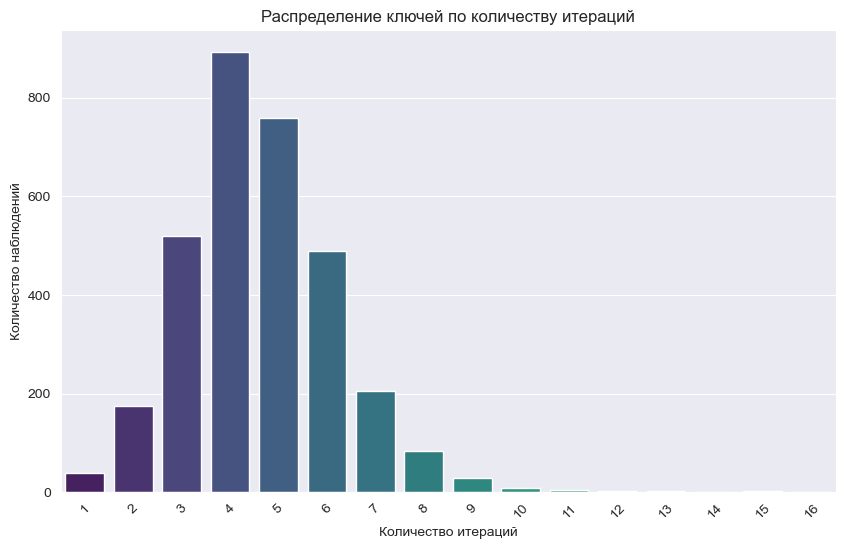

In [12]:
key_counts = arc_df['key'].value_counts()

frequency_distribution = key_counts.value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=frequency_distribution.index, y=frequency_distribution.values,
            palette='viridis')
plt.title('Распределение ключей по количеству итераций')
plt.xlabel('Количество итераций')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=45)

plt.show()

**Промежуточный вывод:**  
>_Визуализировав распределение можно заметить, что подавляющее большинство  
циклов выплавки стали проводится за промежуток от 3 до 6 итераций.  
Однако некоторые кейсы потребовали вплоть до 16 итераций._

In [13]:
arc_df.describe()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876.000000,14876,14876,14876.000000,14876.000000
mean,1615.220422,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479919
25%,806.000000,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,1617.000000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2429.000000,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,3241.000000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,934.571502,NaN,NaN,0.258885,5.873449


**Промежуточный вывод:**
>_Начало первого нагрева стали графитовыми электродами пришлось  
на 2019-05-03 11:02, последний нагрев был окончен 2019-09-06 17:26.  
Таким образом, данные в датасете представлены за период, равный 126 дням._  
>
>**Активная мощность (P):**
>
>_**P = V ⋅ I ⋅ cosφ**_
>
>Где:
>
>**P** — активная мощность (измеряется в ваттах, Вт).
>
>**V** — напряжение (измеряется в вольтах, В).
>
>**I** — ток (измеряется в амперах, А).
>
>**cosφ** — коэффициент мощности, который равен косинусу угла между напряжением и током.
>
>**P** — это мощность, которая непосредственно преобразуется в полезную работу,  
например, в необходимое нам тепло. В контексте работы графитовых  
электродов на сталелитейном предприятии активная мощность определяет  
количество электрической энергии, которая используется для  
расплавления стали в ковше.
>
>**Реактивная мощность (Q):**
>
>_**Q = V ⋅ I ⋅ sinφ**_
>
>Где:
>
>**Q** — реактивная мощность (измеряется в вольт-амперах реактивных, вар).
>
>**V** — напряжение (измеряется в вольтах, В).
>
>**I** — ток (измеряется в амперах, А).
>
>**sinφ** — синус угла между напряжением и током.
>
>**Q** — это мощность, которая не выполняет полезную работу, но необходима для  
создания магнитных и электрических полей в оборудовании, таком как трансформаторы  
и индуктивные нагрузки. В случае с дуговыми печами, графитовые электроды также  
создают магнитные поля, и поддержание этих полей требует определенной  
реактивной мощности.


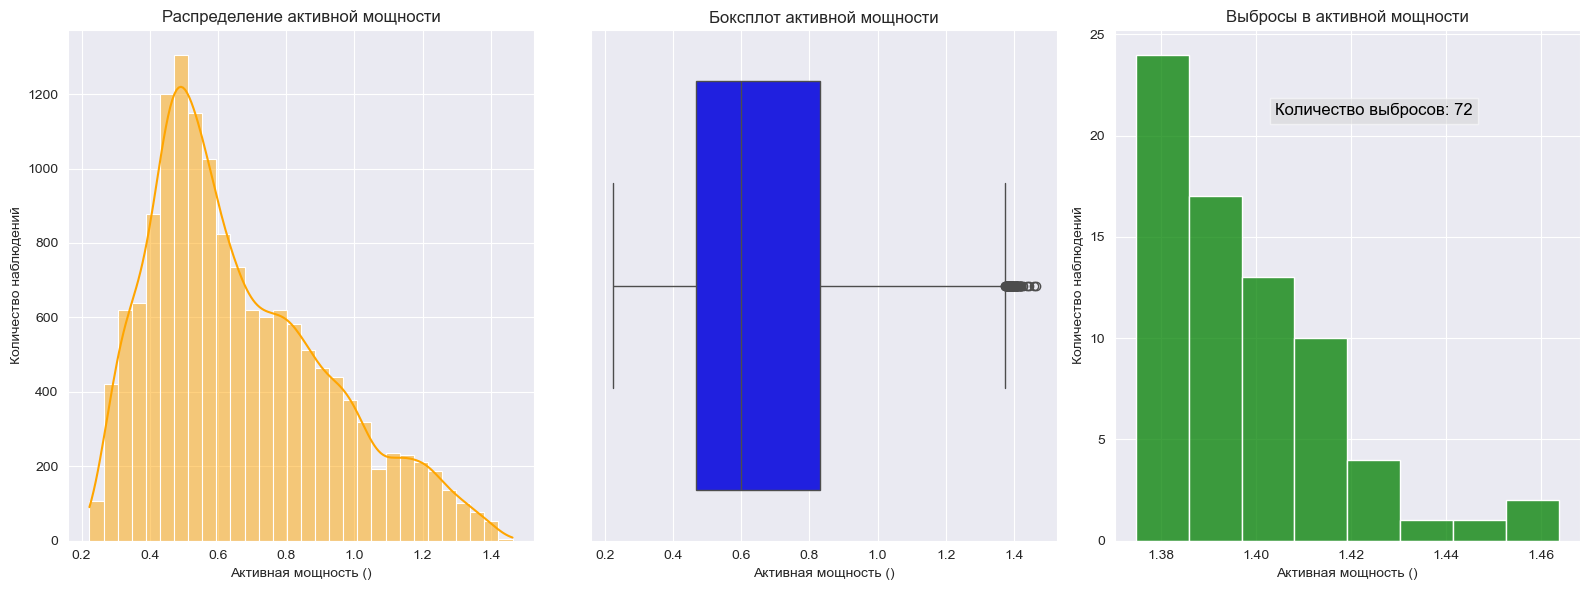

In [14]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.histplot(arc_df['Активная мощность'], kde=True, color='orange', bins=30)
plt.title('Распределение активной мощности')
plt.xlabel('Активная мощность ()')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 2)
boxplot = sns.boxplot(x=arc_df['Активная мощность'], color='blue')
plt.title('Боксплот активной мощности')
plt.xlabel('Активная мощность ()')

outliers = [line.get_xdata() for line in boxplot.get_lines() if
            line.get_linestyle() == 'None']
outliers = [item for sublist in outliers for item in sublist]

plt.subplot(1, 3, 3)
sns.histplot(x=outliers, color='green')
plt.title('Выбросы в активной мощности')
plt.ylabel('Количество наблюдений')
plt.xlabel('Активная мощность ()')

plt.figtext(0.8, 0.8, f'Количество выбросов: {len(outliers)}', fontsize=12,
            color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

plt.tight_layout()
plt.show()


**Промежуточный вывод:**  
>_Самое высокое зафиксированное значение активной мощности на электродах находится  
на отметке в 1.46, самое низкое — 0.22. Медиана набора равняется 0.59,  
а стандартное отклонение — 0.25._  
 
>_Стандартный алгоритм дифференцирования экстремальных значений от общей массы  
наблюдений библиотеки **Seaborn** выявил 72 выброса.  
На данном этапе исследования нет возможности судить, являются ли эти значения  
аномалиями или нет. Форма распределения тяготеет к распределению Пуассона._  


**Примечание:**  
>_Перед исследованием данных о реактивной мощности нагрева дугой, стоит обратить  
внимание на экстремально низкое значение в [-715], если принять во внимание  
внешний вид уравнения, можно заметить, что отрицательные значения для этой  
величины допустимы, это происходит в случаях, когда синус меньше нуля.  
Однако нагрузка в нашей технологической модели явно индуктивная, а не ёмкостная,  
следовательно, синус отрицательным быть не может, значит мы имеем дело с ошибкой  
сбора данных. Исключим аномалию из рассмотрения и повторим исследование._

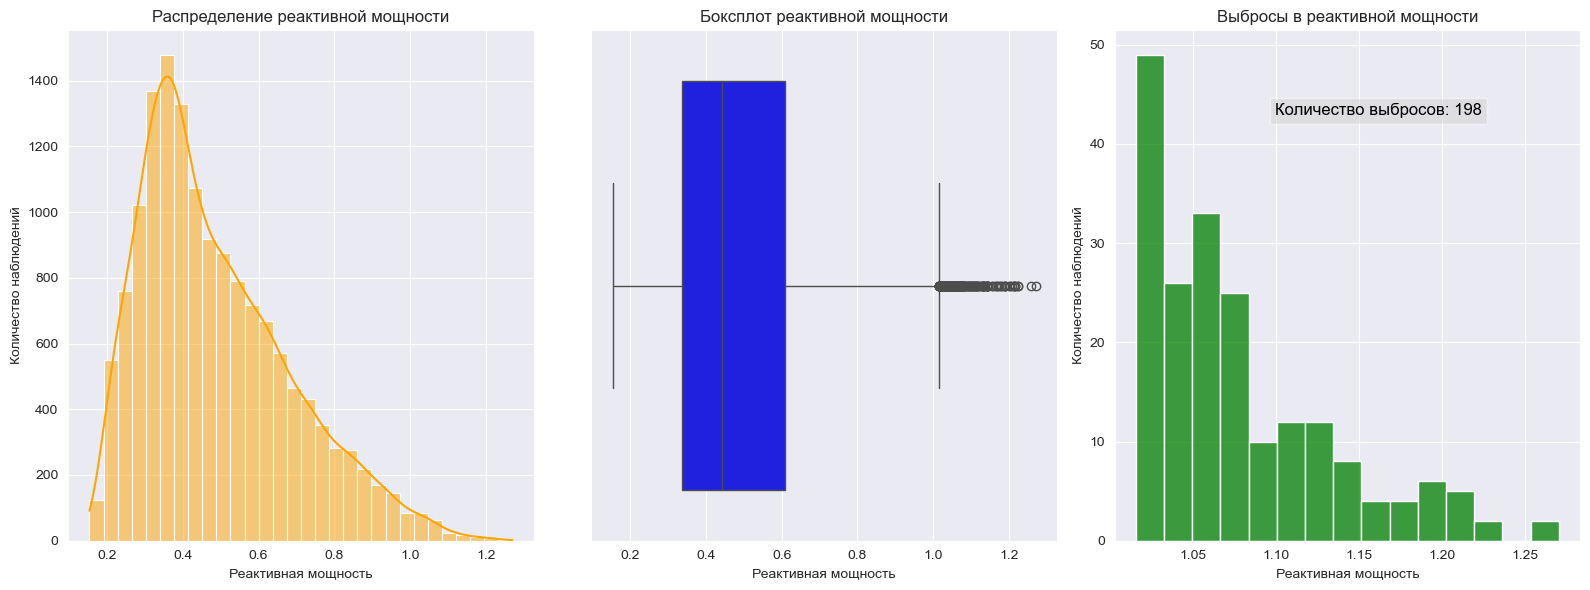

In [15]:
filtered_arc_df = arc_df[arc_df['Реактивная мощность'] >= 0]

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.histplot(filtered_arc_df['Реактивная мощность'], kde=True, color='orange',
             bins=30)
plt.title('Распределение реактивной мощности')
plt.xlabel('Реактивная мощность')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 2)
boxplot = sns.boxplot(x=filtered_arc_df['Реактивная мощность'], color='blue')
plt.title('Боксплот реактивной мощности')
plt.xlabel('Реактивная мощность')

outliers = [line.get_xdata() for line in boxplot.get_lines() if
            line.get_linestyle() == 'None']
outliers = [item for sublist in outliers for item in sublist if
            item >= 0]

plt.subplot(1, 3, 3)
sns.histplot(x=outliers, color='green', bins=15)
plt.title('Выбросы в реактивной мощности')
plt.xlabel('Реактивная мощность')
plt.ylabel('Количество наблюдений')

plt.figtext(0.8, 0.8, f'Количество выбросов: {len(outliers)}', fontsize=12,
            color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

plt.tight_layout()
plt.show()


**Промежуточный вывод:**
>_Самое высокое зафиксированное значение реактивной мощности на электродах находится  
на отметке в 1.27, самое низкое — 0.15. Медиана набора равняется 0.44,  
а стандартное отклонение — 0.19. Стоит отметить, что удаление из рассмотрения  
аномально низкого значения снизило стандартное отклонение величины в 30 раз.  
Количество записей уменьшилось на одну строку, как и предполагалось,  
корректно собранные данные отражают индуктивную природу нагрузки._  

>_Стандартный алгоритм дифференцирования экстремальных значений от общей массы  
наблюдений библиотеки **Seaborn** выявил 198 выбросов. На данном этапе  
исследования нет возможности однозначно сказать являются эти значения  
аномалиями или нет. Форма распределения тяготеет Пуассоновской._

>_Два последних признака **P** и **Q** могут быть использованы на этапе feature-engineering.  
Если взять квадратный корень из суммы квадратов этих величин,  
то можно получить полную мощность системы **S**._



## ➢ Данные о времени нагрева расплава

**Примечание:**  
>_Изучая данные о времени начала и окончания нагрева металла, рассмотрим  
не только информацию по каждому циклу, но и полное время обработки расплава._

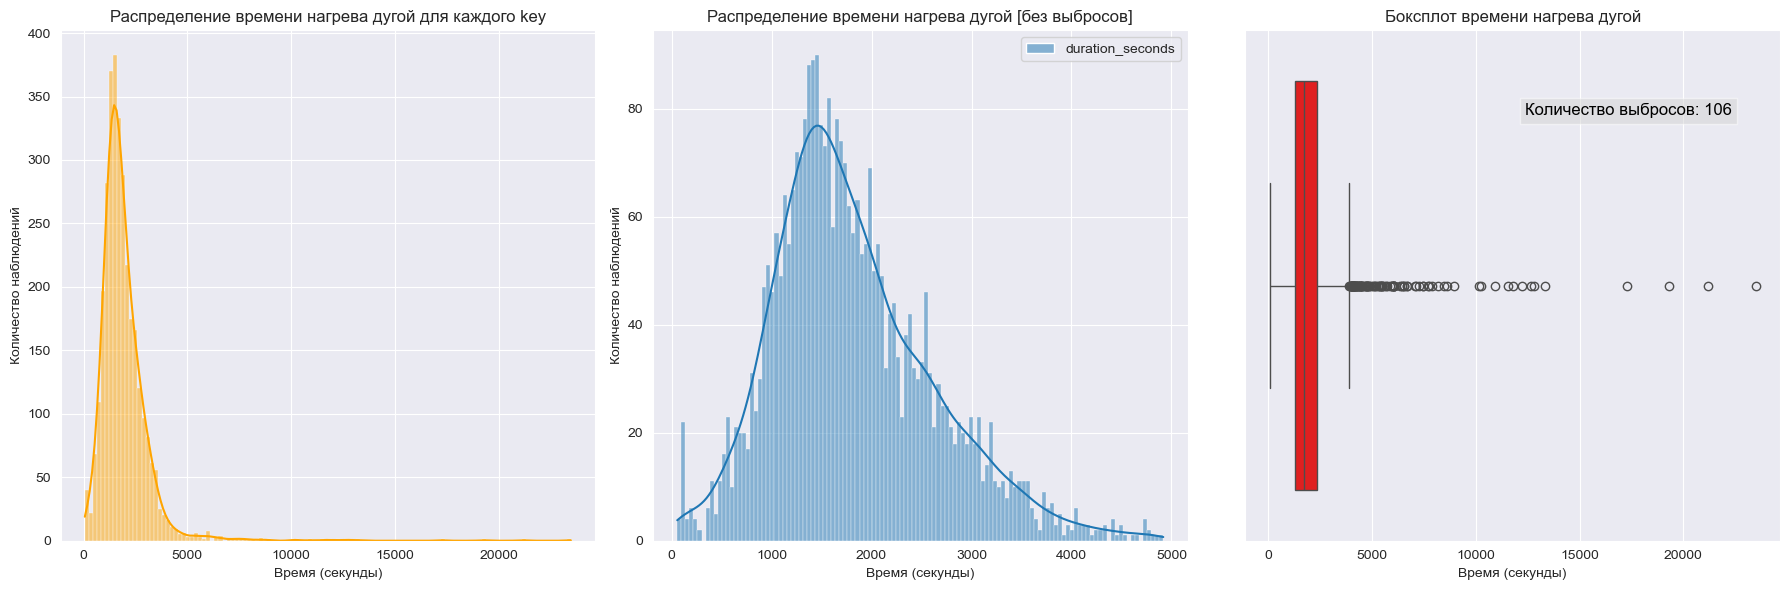

In [16]:
grouped = arc_df.groupby('key').agg(
    first_start=('Начало нагрева дугой', 'min'),
    last_end=('Конец нагрева дугой', 'max')
)

grouped['duration_seconds'] = (
        grouped['last_end'] - grouped['first_start']).dt.total_seconds()
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.histplot(grouped['duration_seconds'], kde=True, bins=120, color='orange')
plt.title('Распределение времени нагрева дугой для каждого key')
plt.xlabel('Время (секунды)')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 2)
sns.histplot(grouped[grouped['duration_seconds'] < 5000], kde=True, bins=120,
             color='orange')
plt.title('Распределение времени нагрева дугой [без выбросов]')
plt.xlabel('Время (секунды)')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 3)
boxplot = sns.boxplot(x=grouped['duration_seconds'], color='red')
plt.title('Боксплот времени нагрева дугой')
plt.xlabel('Время (секунды)')

outliers = [line.get_xdata() for line in boxplot.get_lines() if
            line.get_linestyle() == 'None']
outliers = [item for sublist in outliers for item in sublist]

plt.figtext(0.85, 0.8, f'Количество выбросов: {len(outliers)}', fontsize=12,
            color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

plt.tight_layout()
plt.show()


 **Промежуточный вывод:**  
>_Исследуемый показатель имеет достаточно большое значение размаха,  
6.5 часов разделяют самый короткий и самый длительный полный цикл  
прогрева стали. Медиана набора равняется 1691 секунде со стандартным отклонением  
в 1274 секунды. Если убрать экстремально долгие выплавки, превышающие 5000 секунд,  
как это сделано на втором полотне, то можно заметить, что распределение тяготеет  
к нормальному, с небольшим скосом вправо._

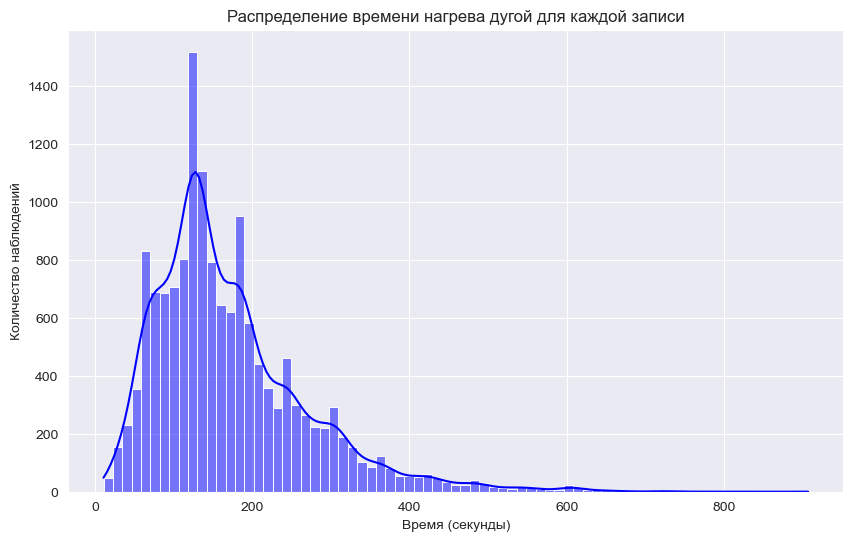

count    14876.000000
mean       171.670946
std         98.186803
min         11.000000
25%        107.000000
50%        147.000000
75%        214.000000
max        907.000000
Name: duration_seconds, dtype: float64

In [17]:
arc_df['duration_seconds'] = (arc_df['Конец нагрева дугой'] - arc_df[
    'Начало нагрева дугой']).dt.total_seconds()

plt.figure(figsize=(10, 6))
sns.histplot(arc_df['duration_seconds'], kde=True, bins=75, color='blue')
plt.title('Распределение времени нагрева дугой для каждой записи')
plt.xlabel('Время (секунды)')
plt.ylabel('Количество наблюдений')
plt.show()

arc_df['duration_seconds'].describe()


 **Промежуточный вывод:**  
>_Типичными значениями длительности одной итерации нагрева можно считать  
временные промежутки от 100 до 200 секунд. Максимальное время прогрева 907 секунд,  
это почти в 6 раз превышает медианное значение набора. Стандартное отклонение  
равняется 98 секундам._

## ➢ Данные об объёме сыпучих материалов

In [18]:
bulk_mb_before = get_dataframe_memory_usage(bulk_df)

bulk_df = bulk_df.astype(
    {col: 'float32' for col in bulk_df.columns if col != 'key'})

bulk_mb_after = get_dataframe_memory_usage(bulk_df)

print(
    f"Объём датафрейма до приведения типов: {bulk_mb_before}MB\n"
    f"Объём датафрейма после приведения типов: {bulk_mb_after}MB")

Объём датафрейма до приведения типов: 0.38MB
Объём датафрейма после приведения типов: 0.2MB



**Промежуточный вывод:**  
>_После преобразования типов данных затраты памяти снизились в 2 раза._

**Примечание:**  
>_Уже имеющиеся данные об объёмах сыпучих материалов, подаваемых в сплав для  
достижения металлом необходимых свойств можно дополнить несколькими  
интегральными признаками: "общий объем материалов, затраченных на партию",  
"суммарный объём каждой добавки, использованной за время наблюдений"._

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,total_additives
303,322,185.0,NaN,101.0,58.0,NaN,NaN,406.0,NaN,NaN,NaN,NaN,1849.0,NaN,636.0,NaN,3235.0
1629,1689,NaN,NaN,NaN,NaN,NaN,247.0,NaN,NaN,NaN,NaN,NaN,733.0,305.0,248.0,224.0,1757.0
308,327,67.0,NaN,NaN,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,775.0,NaN,403.0,205.0,1569.0
1933,1999,54.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,853.0,NaN,366.0,290.0,1563.0
486,513,NaN,NaN,286.0,NaN,NaN,295.0,NaN,NaN,NaN,NaN,NaN,474.0,NaN,219.0,224.0,1498.0
1976,2046,NaN,NaN,80.0,242.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,620.0,NaN,292.0,209.0,1443.0
485,512,NaN,NaN,62.0,NaN,NaN,264.0,NaN,NaN,NaN,NaN,131.0,528.0,NaN,220.0,225.0,1430.0
1819,1881,NaN,NaN,29.0,NaN,NaN,330.0,NaN,NaN,NaN,NaN,198.0,462.0,NaN,201.0,206.0,1426.0
418,444,52.0,NaN,NaN,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,671.0,NaN,379.0,203.0,1420.0
1311,1363,NaN,NaN,85.0,NaN,NaN,283.0,NaN,NaN,NaN,NaN,NaN,411.0,NaN,375.0,210.0,1364.0


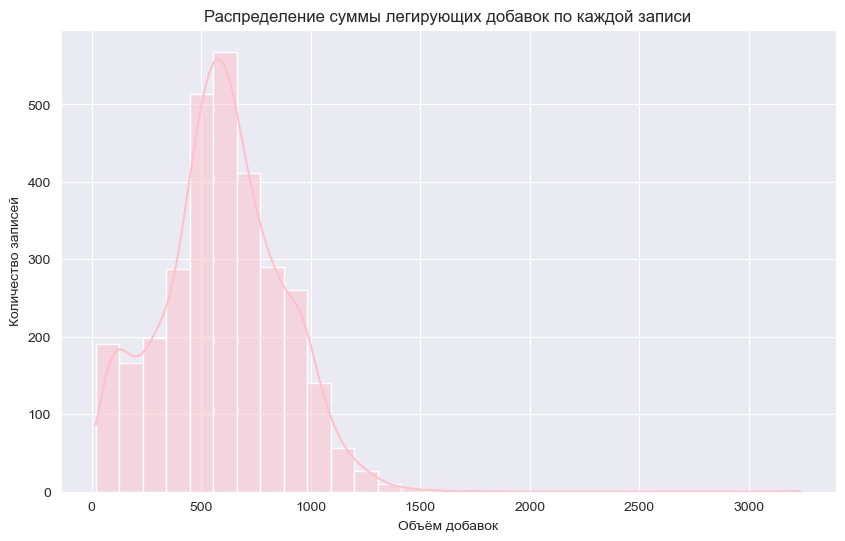

count    3129.000000
mean      595.503357
std       276.557983
min        19.000000
25%       429.000000
50%       591.000000
75%       772.000000
max      3235.000000
Name: total_additives, dtype: float64

In [19]:
bulk_df['total_additives'] = bulk_df.drop(columns=['key']).sum(axis=1)

top_10_bulk = bulk_df.sort_values(by='total_additives', ascending=False).head(
    10)

display(HTML("<h3>10 самых затратных партий</h3>"))
display(top_10_bulk)

plt.figure(figsize=(10, 6))
sns.histplot(bulk_df['total_additives'], kde=True, bins=30, color='pink')
plt.title('Распределение суммы легирующих добавок по каждой записи')
plt.xlabel('Объём добавок')
plt.ylabel('Количество записей')
plt.show()

bulk_df['total_additives'].describe()

**Промежуточный вывод:**  
>_Вновь можно наблюдать очень большой размах для набора, максимум и минимум  
разделяет 3216 единиц³. На типичную партию уходит от 430 до 770 единиц³  
сыпучих добавок. Медиана равняется 590 со стандартным отклонением в 275 единиц³.  
Распределение тяготеет к распределению Пуассона. Отдельно была сформирована  
таблица партий-лидеров по суммарному объёму используемых сыпучих, легирующих  
добавок. Учитывая специфику предметной области, на данном этапе нет возможности  
говорить об аномальной природе наиболее крупных и мелких наблюдений, возможно  
необходимый объём для конкретных партий добирался проволочными материалами либо  
не требовался вовсе._

,Общий объём материала,Процент от общего объёма,Количество добавлений
Bulk 12,638154.0,34.248039,2450
Bulk 14,477819.0,25.643284,2806
Bulk 15,360834.0,19.365007,2248
Bulk 3,147815.0,7.932841,1298
Bulk 4,105856.0,5.681012,1014
Bulk 6,68501.0,3.676268,576
Bulk 10,14658.0,0.786656,176
Bulk 11,13597.0,0.729715,177
Bulk 1,9889.0,0.530716,252
Bulk 5,8241.0,0.442273,77


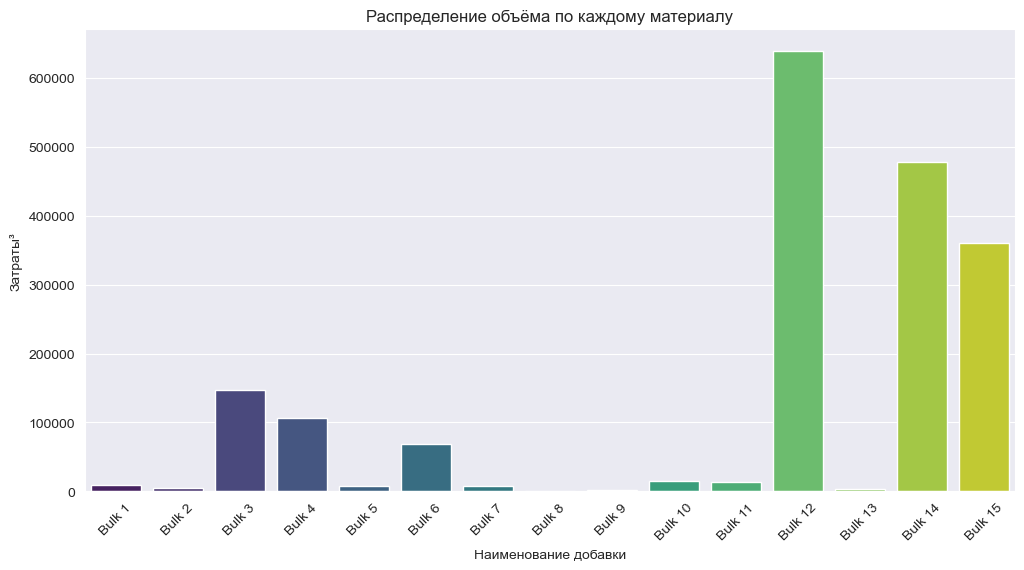

In [20]:
column_sums = bulk_df.drop(columns=['key', 'total_additives']).sum(axis=0,
                                                                   skipna=True)

column_sums_df = pd.DataFrame(column_sums, columns=['Общий объём материала'])

column_sums_df['Процент от общего объёма'] = (column_sums_df[
                                                  'Общий объём материала'] /
                                              column_sums_df[
                                                  'Общий объём материала'].sum()) * 100

sorted_column_sums_df = column_sums_df.sort_values(by='Общий объём материала',
                                                   ascending=False)

non_zero_counts = bulk_df.drop(columns=['key', 'total_additives']).apply(
    lambda x: (x > 0).sum(), axis=0)

non_zero_counts_df = pd.DataFrame(non_zero_counts,
                                  columns=['Количество добавлений'])

merged_df = pd.concat([sorted_column_sums_df, non_zero_counts_df], axis=1)

display(HTML("<h3>Суммарные затраты и частота добавления</h3>"), merged_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=column_sums.index, y=column_sums.values, palette="viridis")
plt.title('Распределение объёма по каждому материалу')
plt.xlabel('Наименование добавки')
plt.ylabel('Затраты³')
plt.xticks(rotation=45)
plt.show()

**Промежуточный вывод:**  
>_Исследование интегрально сформированного признака помогло выявить некоторые  
закономерности, оказалось, что легирующие добавки под кодовыми номерами  
12, 14, 15 использовались чаще всего. На долю 12 добавки приходится 34% от  
общей массы использованных сыпучих материалов, однако наиболее часто применяемым  
компонентом является добавка 14, 2806 добавлений против 2450._

In [21]:
bulk_df.drop(['key', 'total_additives'], axis=1).describe()

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242062,253.045456,113.879044,104.394478,107.025970,118.925346,305.600006,49.0,76.315788,83.284088,76.819206,260.471008,181.111115,170.284744,160.513351
std,18.277639,21.180578,75.483505,48.184109,81.790642,72.057755,191.022903,NaN,21.720581,26.060350,59.655350,120.649605,46.088009,65.868668,51.765217
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


**Промежуточный вывод:**  
>_Рассматривая каждый легирующий компонент в отдельности можно заметить, что  
данные не содержат противоречивых сведений, отсутствуют отрицательные значения,  
что свидетельствует о высоком качестве сбора и обработки информации.  
Для добавки под номером 8 зафиксировано включение в расплав всего один  
раз, как ранее было отмечено в таблице частоты встречаемости добавок.  
Признак с такой низкой дисперсией не сможет существенно повысить обобщающие  
свойства будущей модели._


**Примечание:**  
>_Полноте исследования поспособствует построение матрицы корреляций сыпучих  
присадок, однако на практике выявлена сильная разреженность для большинства  
исследуемых пар. Эта проблема будет решена на более позднем этапе работы._

## ➢ Валидация времени подачи сыпучих материалов

In [22]:
bulk_time_mb_before = get_dataframe_memory_usage(bulk_time_df)

bulk_time_df = bulk_time_df.astype(
    {col: 'datetime64[ns]' for col in bulk_time_df.columns if col != 'key'})

bulk_time_mb_after = get_dataframe_memory_usage(bulk_time_df)

print(
    f"Объём датафрейма до приведения типов: {bulk_time_mb_before}MB\n"
    f"Объём датафрейма после приведения типов: {bulk_time_mb_after}MB")

Объём датафрейма до приведения типов: 1.84MB
Объём датафрейма после приведения типов: 0.38MB


**Промежуточный вывод:**  
>_Преобразование типов данных позволило сократить затраты памяти в 5 раз и  
оптимизировать последующую работу с датафреймом._

In [23]:
bulk_df_not_null_count = bulk_df.drop(
    columns=['total_additives']).notnull().sum().sum()

bulk_time_df_not_null_count = bulk_time_df.notnull().sum().sum()

print(f"Количество ненулевых значений в bulk_df: {bulk_df_not_null_count}")
print(
    f"Количество ненулевых значений в bulk_time_df: {bulk_time_df_not_null_count}")

Количество ненулевых значений в bulk_df: 14288
Количество ненулевых значений в bulk_time_df: 14288


**Промежуточный вывод:**  
>_Эта проверка помогла понять, что время внесения каждой легирующей добавки  
задокументировано, количество notnull значений совпадает для двух датасетов._

## ➢ Данные об объёме подаваемого газа

In [24]:
display(HTML("<h3>Описательная статистика объёма подаваемого газа</h3>"))
gas_df.drop('key', axis=1).describe()

,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


In [25]:
if gas_df.isna().sum().sum() > 0:
    print("Некоторые записи содержат пропуски")
else:
    print("Для каждой записи есть информация об объёме подаваемого газа")

Для каждой записи есть информация об объёме подаваемого газа


**Промежуточный вывод:**  
>_Размах набора составляет 77.99 единиц³. Медиана 9.83 со стандартным  
отклонением в 6.22 единицы³._ 

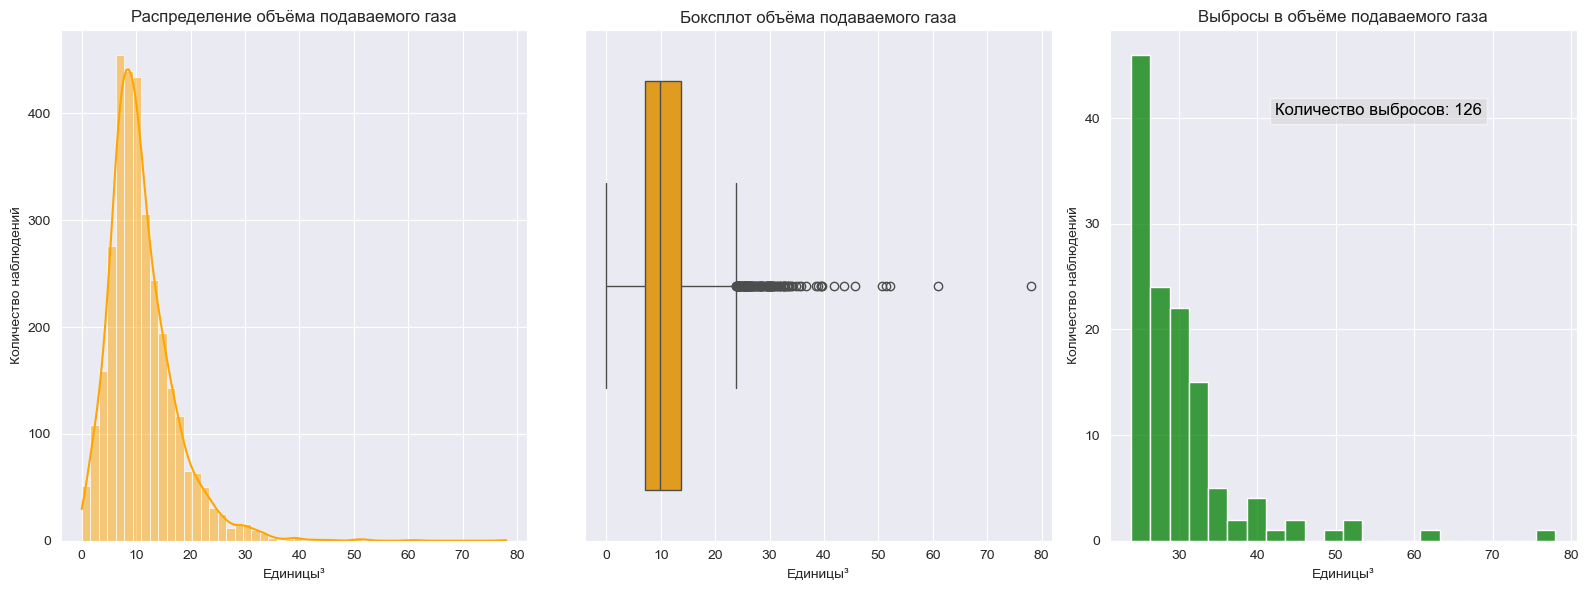

In [26]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.histplot(gas_df['Газ 1'], kde=True, color='orange', bins=50)
plt.title('Распределение объёма подаваемого газа')
plt.xlabel('Единицы³')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 2)
boxplot = sns.boxplot(x=gas_df['Газ 1'], color='orange')
plt.title('Боксплот объёма подаваемого газа')
plt.xlabel('Единицы³')

outliers = [line.get_xdata() for line in boxplot.get_lines() if
            line.get_linestyle() == 'None']
outliers = [item for sublist in outliers for item in sublist]

plt.subplot(1, 3, 3)
sns.histplot(x=outliers, color='green')
plt.title('Выбросы в объёме подаваемого газа')
plt.ylabel('Количество наблюдений')
plt.xlabel('Единицы³')

plt.figtext(0.8, 0.8, f'Количество выбросов: {len(outliers)}', fontsize=12,
            color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

plt.tight_layout()
plt.show()

**Промежуточный вывод:**  
>_В наборе содержится полная информация об объёмах поданного газа, датасет не  
содержит пропусков. Учитывая специфику предметной области, на данном  
этапе нет возможности дифференцировать аномальные значения от типичных.  
На первый взгляд все записи выглядят правдоподобно. Распределение объёма тяготеет  
к распределению Пуассона, алгоритм выделил 126 экстремальных значений._

## ➢ Данные о температуре стали

In [27]:
temp_mb_before = get_dataframe_memory_usage(temp_df)

temp_df['Время замера'] = pd.to_datetime(temp_df['Время замера'])
temp_df['Температура'] = temp_df['Температура'].astype('float32')

temp_mb_after = get_dataframe_memory_usage(temp_df)

print(
    f"Объём датафрейма до приведения типов: {temp_mb_before}MB\n"
    f"Объём датафрейма после приведения типов: {temp_mb_after}MB")

Объём датафрейма до приведения типов: 1.45MB
Объём датафрейма после приведения типов: 0.35MB


**Промежуточный вывод:**  
>_Преобразование типов данных позволило снизить затраты памяти в 4 раза.  
Это один из наиболее важных для решения задачи машинного обучения датасетов,  
так как он содержит целевой признак - температуру._

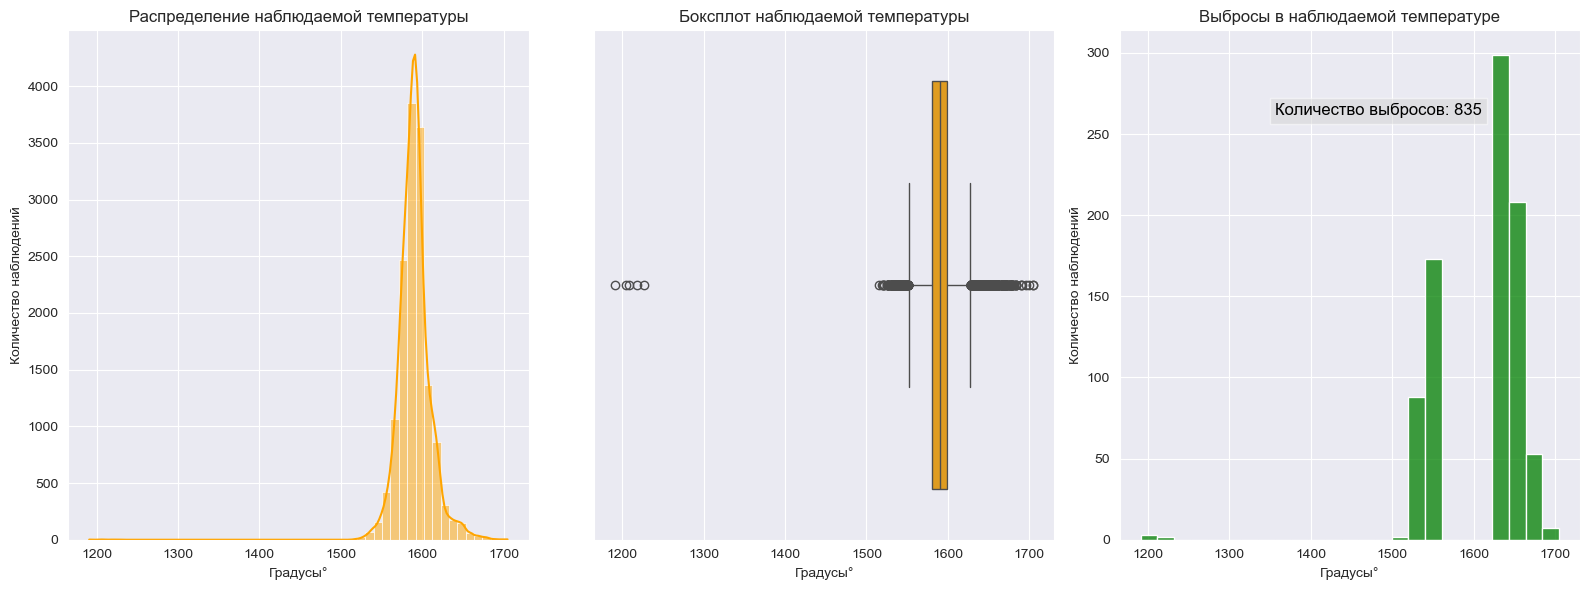

count    14665.000000
mean      1590.722778
std         20.394419
min       1191.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: Температура, dtype: float64

In [28]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.histplot(temp_df['Температура'], kde=True, color='orange', bins=50)
plt.title('Распределение наблюдаемой температуры')
plt.xlabel('Градусы°')
plt.ylabel('Количество наблюдений')

plt.subplot(1, 3, 2)
boxplot = sns.boxplot(x=temp_df['Температура'], color='orange')
plt.title('Боксплот наблюдаемой температуры')
plt.xlabel('Градусы°')

outliers = [line.get_xdata() for line in boxplot.get_lines() if
            line.get_linestyle() == 'None']
outliers = [item for sublist in outliers for item in sublist]

plt.subplot(1, 3, 3)
sns.histplot(x=outliers, color='green')
plt.title('Выбросы в наблюдаемой температуре')
plt.ylabel('Количество наблюдений')
plt.xlabel('Градусы°')

plt.figtext(0.8, 0.8, f'Количество выбросов: {len(outliers)}', fontsize=12,
            color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

plt.tight_layout()
plt.show()

temp_df['Температура'].describe()

In [29]:
missing_target = temp_df['Температура'].isna().sum()

key_counts = temp_df['key'].value_counts()
single_keys = key_counts[key_counts == 1].count()

temperature_below_1500_count = temp_df[temp_df['Температура'] < 1500].shape[0]

total_bads = missing_target + single_keys + temperature_below_1500_count

percent_bads = total_bads / temp_df.shape[0] * 100

print(
    f"\nСтрок с пропусками в целевой переменной: {missing_target}",
    f"\nСтрок с единичными замером: {single_keys}",
    f"\nСтрок с температурой ниже 1500°: {temperature_below_1500_count}",
    f"\nОбщий процент испорченных записей {percent_bads:.2f}%")


Строк с пропусками в целевой переменной: 3427 
Строк с единичными замером: 2 
Строк с температурой ниже 1500°: 5 
Общий процент испорченных записей 18.98%


**Промежуточный вывод:**  
>_На данном этапе исследовательского анализа удалось обнаружить серьёзную проблему  
в данных, почти пятая часть записей содержит пропуски на месте целевой  
переменной, что делает такие записи бесполезными при решении задачи регрессии.  
Импутация значений целевой переменной для такого крупного процента записей  
может серьезно исказить распределение величины и снизить обобщающую способность  
будущих моделей, оставим этот способ, как запасной, на случай, если качество  
метрики не будет удовлетворять условиям заказчика исследования.  
Одним из условий является удаление всех записей, для которых значение  
температуры ниже 1500 градусов, а так же число замеров равняется одному._

>_Принимая во внимание вышеперечисленные факторы, удалось рассчитать, что  
безвозвратно потеряно будет 19% всех записей (3434 строки).  
Природа пропусков остается неясной, вероятность ошибки сбора не велика, если  
рассматривать общее качество подготовки датасетов.  
Интересно, что несмотря на немалое количество экстремально высоких значений  
температуры, медиана распределения с точностью до десятых долей равняется  
среднему значению. Для актуальных данных размах составит 205 градусов°,  
со стандартным отклонением около 20 градусов°._

## ➢ Данные о подаче проволочных материалов

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,total_additives
2381,2508,175.637275,219.866410,268.348081,NaN,NaN,NaN,NaN,NaN,NaN,663.851766
2374,2501,172.754410,198.452789,254.462219,NaN,NaN,NaN,NaN,NaN,NaN,625.669418
2759,2912,190.095352,80.346243,327.233753,NaN,NaN,NaN,NaN,NaN,NaN,597.675348
1750,1840,200.210403,80.135117,288.432144,NaN,NaN,NaN,NaN,NaN,NaN,568.777664
1825,1915,161.091842,22.137440,385.008668,NaN,NaN,NaN,NaN,NaN,NaN,568.237950
2933,3092,127.065116,134.242157,276.179963,NaN,NaN,NaN,NaN,NaN,NaN,537.487236
928,988,160.992004,90.118080,277.092834,NaN,NaN,NaN,NaN,NaN,NaN,528.202918
2380,2507,140.169129,135.358078,250.185944,NaN,NaN,NaN,NaN,NaN,NaN,525.713151
2375,2502,100.551354,160.330566,260.179932,NaN,NaN,NaN,NaN,NaN,NaN,521.061852
375,407,129.261596,108.515679,279.783508,NaN,NaN,NaN,NaN,NaN,NaN,517.560783


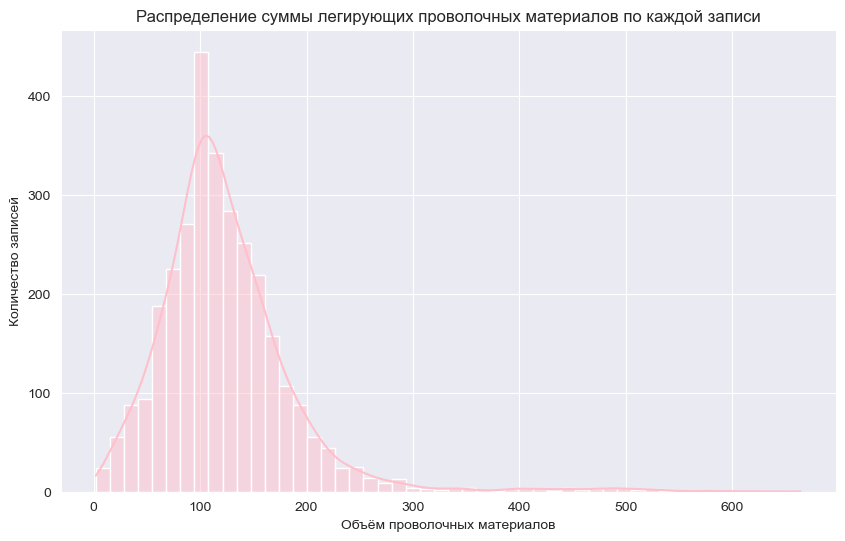

In [30]:
wire_df['total_additives'] = wire_df.drop(columns=['key']).sum(axis=1)

top_10_wire = wire_df.sort_values(by='total_additives', ascending=False).head(
    10)

display(HTML("<h3>10 самых затратных партий</h3>"))
display(top_10_wire)

plt.figure(figsize=(10, 6))
sns.histplot(wire_df['total_additives'], kde=True, bins=50, color='pink')
plt.title(
    'Распределение суммы легирующих проволочных материалов по каждой записи')
plt.xlabel('Объём проволочных материалов')
plt.ylabel('Количество записей')
plt.show()

**Промежуточный вывод:**  
>_Просуммировав расходы проволочных материалов для каждой записи установлено, что  
типичным показателем является объём от 85 до 150 единиц³ на каждую партию.  
Размах набора 661, медиана равная 114 и стандартное отклонение в 66 единиц³.  
Распределение суммарных затрат тяготеет к распределению Пуассона.  
Дополнительно сформирована обзорная таблица, содержащая 10 наиболее затратных  
партий. Легирующих компонентов сплава в сыпучем виде добавляется значительно  
больше, напомню, что медиана набора для них составила 591 единицу³, а  
максимум находился в районе 3235 единиц³._

,Общий объём материала,Процент от общего объёма,Количество добавлений
Wire 1,308236.830606,80.861398,3055
Wire 2,54572.931650,14.316406,1079
Wire 3,11937.408916,3.131604,63
Wire 6,3505.239099,0.919548,73
Wire 8,1018.878666,0.267288,19
Wire 9,990.516814,0.259848,29
Wire 4,804.199781,0.210970,14
Wire 7,110.429080,0.028969,11
Wire 5,15.132000,0.003970,1


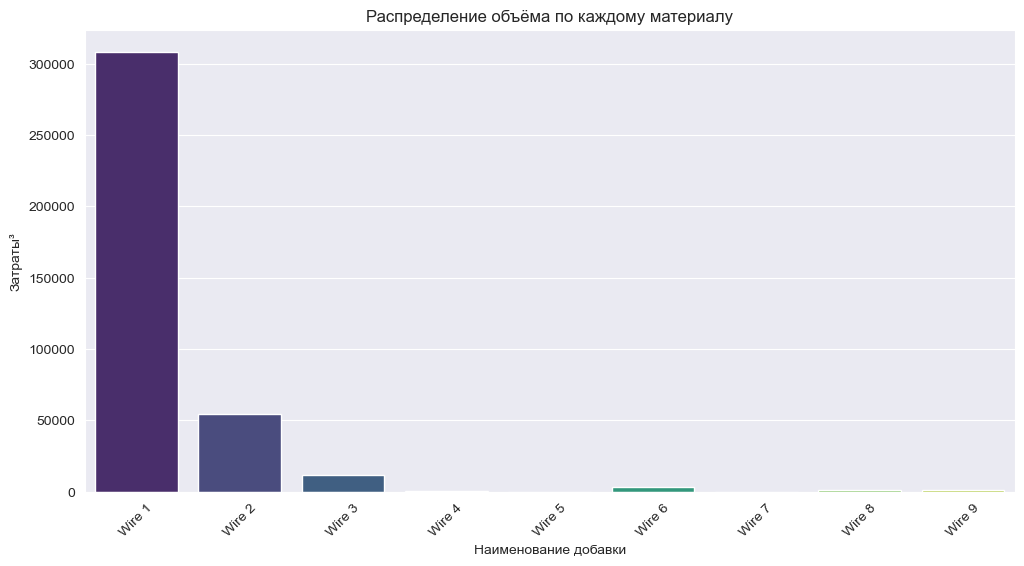

In [31]:
column_sums = wire_df.drop(columns=['key', 'total_additives']).sum(axis=0,
                                                                   skipna=True)

column_sums_df = pd.DataFrame(column_sums, columns=['Общий объём материала'])

column_sums_df['Процент от общего объёма'] = (column_sums_df[
                                                  'Общий объём материала'] /
                                              column_sums_df[
                                                  'Общий объём материала'].sum()) * 100

sorted_column_sums_df = column_sums_df.sort_values(by='Общий объём материала',
                                                   ascending=False)

non_zero_counts = wire_df.drop(columns=['key', 'total_additives']).apply(
    lambda x: (x > 0).sum(), axis=0)

non_zero_counts_df = pd.DataFrame(non_zero_counts,
                                  columns=['Количество добавлений'])

merged_df = pd.concat([sorted_column_sums_df, non_zero_counts_df], axis=1)

display(HTML("<h3>Суммарные затраты и частота добавления</h3>"), merged_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=column_sums.index, y=column_sums.values, palette="viridis")
plt.title('Распределение объёма по каждому материалу')
plt.xlabel('Наименование добавки')
plt.ylabel('Затраты³')
plt.xticks(rotation=45)
plt.show()

In [32]:
wire_df.drop(['key', 'total_additives'], axis=1).describe()

,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


**Промежуточный вывод:**  
>_Наиболее популярной проволочной легирующей добавкой оказалась Wire 1,  
3055 случаев применения и 80% от общего объёма использованных материалов  
приходится именно на неё. Компонент Wire 2 занимает второе место  
по частоте применения и общему объёму.  
Расход на одну партию для двух этих номеров достигает 330 и 280 единиц³.  
Медиана набора для первой проволочной добавки 100, со стандартным отклонением  
в 42 единицы³. Для второй добавки медиана и стандартное отклонение равны  
40 единицам³.  
Мы вновь, аналогично пункту с анализом сыпучих легирующих добавок, получили  
очень разреженный датасет. Для 7 из 9 видов проволок, суммарное количество  
нулевых значений в строках значительно превышает 80%, которые заказчик  
выбрал, как порог значимости._


## ➢ Данные о времени подачи проволочных материалов

In [33]:
wire_time_mb_before = get_dataframe_memory_usage(bulk_time_df)

wire_time_df = wire_time_df.astype(
    {col: 'datetime64[ns]' for col in wire_time_df.columns if col != 'key'})

wire_time_mb_after = get_dataframe_memory_usage(wire_time_df)

print(
    f"Объём датафрейма до приведения типов: {wire_time_mb_before}MB\n"
    f"Объём датафрейма после приведения типов: {wire_time_mb_after}MB")

Объём датафрейма до приведения типов: 0.38MB
Объём датафрейма после приведения типов: 0.24MB


**Промежуточный вывод:**  
>_Изменение типов данных позволило сократить затраты памяти на хранение датасета  
в 1.5 раза._

**Примечание:**  
>_Эта проверка помогла понять, что время внесения каждой проволочной  
легирующей добавки задокументировано, количество notnull значений совпадает  
для двух датасетов._

## Вывод шага Ⅱ: 
_На этапе исследования мною был проведен предварительный анализ всех  
данных, полученных от заказчика исследования. На основе **.csv-таблиц** созданы  
7 датафреймов. Изучены характеристики распределений ключевых величин, сформирована  
описательная статистика, для наиболее актуальных и интерпретируемых  
показателей были подготовлены наборы визуализаций.  
Предварительное исследование помогло выявить несколько ключевых моментов,  
которые окажут влияние на дальнейшую подготовку данных к обучению моделей._

>**Данные об электродах**  
Нуждаются в группировке по ключу перед объединением данных в  
генеральную таблицу. Для значений активной и реактивных мощностей допустимы  
несколько вариантов обработки, например формирование интегрального признака  
"Полная мощность", однако я склоняюсь к расчёту среднего значения каждой  
переменной после группировки.  
Многообразие временных меток для этого набора предлагаю урезать, взяв  
время начала нагрева и время его окончания.  
Не забудем удалить строку с отрицательной реактивной мощностью.

>**Сыпучие присадки**  
Количество пропусков столь велико, что не удается корректно подсчитать  
коэффициент корреляции для многих столбцов. Согласно требованиям заказчика  
удалим все столбцы, для которых количество пропусков превышает 80%.

>**Данные о температуре расплава**  
Один из худших, с точки зрения качества сбора данных датасетов.  
Учитывая все требования заказчика исследования, мы теряем 19% записей,  
большая часть потерь происходит из-за отсутствия целевой переменной, применение  
способов импутации может привести к непредвиденным искусственным ошибкам.  
Для оставшихся данных необходимо произвести группировку по ключу, предлагаю  
сохранить два ключевых температурных показателя, первый и последний, чтобы  
избежать утечки данных.

>**Проволочные присадки**  
Количество пропусков для некоторых величин столь велико, что  
не удается корректно подсчитать коэффициент корреляции для многих столбцов.   
Согласно требованиям заказчика удалим все столбцы, для которых количество  
пропусков превышает 80%.

# Ⅲ Шаг. Предобработка данных

## ➢ Данные об электродах

* Сформировать новые признаки
* Выполнить группировку
* Удалить аномальное значение реактивной мощности

In [34]:
arc_df = arc_df[arc_df['Реактивная мощность'] >= 0]

arc_df['Время_нагрева'] = (arc_df['Конец нагрева дугой'] - arc_df[
    'Начало нагрева дугой']).dt.total_seconds()

arc_grouped = arc_df.groupby('key').agg(
    total_heating_time=('Время_нагрева', 'sum'),
    avg_active_power=('Активная мощность', 'mean'),
    avg_reactive_power=('Реактивная мощность', 'mean')
).reset_index()

arc_grouped.head()

,key,total_heating_time,avg_active_power,avg_reactive_power
0,1,1098.0,0.607346,0.428564
1,2,811.0,0.534852,0.363339
2,3,655.0,0.812728,0.587491
3,4,741.0,0.676622,0.514248
4,5,869.0,0.563237,0.421998


## ➢ Данные о сыпучих присадках

* Удалить неинформативные столбцы (Пропусков более 80%)
* Заполнить пропуски нулями

In [35]:
print('Процент пропусков по каждому столбцу:\n', bulk_df.isna().mean() * 100)

Процент пропусков по каждому столбцу:
 key                 0.000000
Bulk 1             91.946309
Bulk 2             99.296900
Bulk 3             58.517098
Bulk 4             67.593480
Bulk 5             97.539150
Bulk 6             81.591563
Bulk 7             99.201023
Bulk 8             99.968041
Bulk 9             99.392777
Bulk 10            94.375200
Bulk 11            94.343241
Bulk 12            21.700224
Bulk 13            99.424736
Bulk 14            10.322787
Bulk 15            28.155960
total_additives     0.000000
dtype: float64


In [36]:
bulk_df = bulk_df[['key', 'Bulk 3', 'Bulk 4', 'Bulk 12', 'Bulk 14', 'Bulk 15']]
bulk_df.fillna(value=0, inplace=True)
bulk_df.head()

,key,Bulk 3,Bulk 4,Bulk 12,Bulk 14,Bulk 15
0,1,0.0,43.0,206.0,150.0,154.0
1,2,0.0,73.0,206.0,149.0,154.0
2,3,0.0,34.0,205.0,152.0,153.0
3,4,0.0,81.0,207.0,153.0,154.0
4,5,0.0,78.0,203.0,151.0,152.0


## ➢ Данные о температуре стали

* удалить строки, для которых не указано значение температуры
* удалить строки с аномально низким значением температуры
* удалить строки с единственным замером температуры
* сформировать новые признаки
* избегать утечки данных

In [37]:
temp_df = temp_df[temp_df['Температура'] >= 1500]
key_counts = temp_df['key'].value_counts()
temp_df = temp_df[temp_df['key'].isin(key_counts[key_counts > 1].index)]

In [38]:
temp_df.head(15)

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0
7,2,2019-05-03 11:38:40,1577.0
8,2,2019-05-03 11:46:09,1589.0
9,2,2019-05-03 11:49:38,1604.0


In [39]:
grouped_temp_df = temp_df.groupby('key').agg(
    first_measurement=('Время замера', 'min'),
    last_measurement=('Время замера', 'max'),
    first_temperature=('Температура', 'first'),
    last_temperature=('Температура', 'last'),
    iteration_count=('key', 'size')
).reset_index()

grouped_temp_df.head()

,key,first_measurement,last_measurement,first_temperature,last_temperature,iteration_count
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,6
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,5
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,6
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,5
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,5


## ➢ Данные о проволочных присадках

- Удалить неинформативные столбцы (Пропусков более 80%)
- Заполнить пропуски нулями

In [40]:
print('Процент пропусков по каждому столбцу:\n', wire_df.isna().mean() * 100)

Процент пропусков по каждому столбцу:
 key                 0.000000
Wire 1              0.843882
Wire 2             64.978903
Wire 3             97.955209
Wire 4             99.545602
Wire 5             99.967543
Wire 6             97.630639
Wire 7             99.642973
Wire 8             99.383317
Wire 9             99.058747
total_additives     0.000000
dtype: float64


In [41]:
wire_df = wire_df[['key', 'Wire 1', 'Wire 2']]
wire_df.fillna(value=0, inplace=True)
wire_df.head()

,key,Wire 1,Wire 2
0,1,60.059998,0.00000
1,2,96.052315,0.00000
2,3,91.160157,0.00000
3,4,89.063515,0.00000
4,5,89.238236,9.11456


## Вывод шага Ⅲ:
_Данные были обработаны, согласно заметкам в исследовательском дневнике.  
Общее качество подготовки можно оценить, как удовлетворяющее пороговым условиям для  
обучения набора производительных моделей машинного обучения._

# Ⅳ Шаг. Формирование генеральной таблицы 

In [42]:
merged_df = arc_grouped.merge(bulk_df, on='key', how='inner') \
    .merge(grouped_temp_df, on='key', how='inner') \
    .merge(wire_df, on='key', how='inner') \
    .merge(gas_df, on='key', how='inner')

merged_df.drop('key', axis=1, inplace=True)

merged_df = merged_df.rename(columns={
    'Bulk 3': 'bulk_3',
    'Bulk 4': 'bulk_4',
    'Bulk 12': 'bulk_12',
    'Bulk 14': 'bulk_14',
    'Bulk 15': 'bulk_15',
    'Wire 1': 'wire_1',
    'Wire 2': 'wire_2',
    'Газ 1': 'gas',
})

col_order = ['gas', 'wire_1', 'wire_2', 'bulk_3', 'bulk_4', 'bulk_12',
             'bulk_14', 'bulk_15', 'first_temperature', 'last_temperature',
             'total_heating_time', 'first_measurement', 'last_measurement',
             'iteration_count', 'avg_active_power', 'avg_reactive_power']

merged_df = merged_df[col_order]

display(merged_df.head(), merged_df.tail())

,gas,wire_1,wire_2,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,first_temperature,last_temperature,total_heating_time,first_measurement,last_measurement,iteration_count,avg_active_power,avg_reactive_power
0,29.749986,60.059998,0.00000,0.0,43.0,206.0,150.0,154.0,1571.0,1613.0,1098.0,2019-05-03 11:02:04,2019-05-03 11:30:38,6,0.607346,0.428564
1,12.555561,96.052315,0.00000,0.0,73.0,206.0,149.0,154.0,1581.0,1602.0,811.0,2019-05-03 11:34:04,2019-05-03 11:55:09,5,0.534852,0.363339
2,28.554793,91.160157,0.00000,0.0,34.0,205.0,152.0,153.0,1596.0,1599.0,655.0,2019-05-03 12:06:44,2019-05-03 12:35:57,6,0.812728,0.587491
3,18.841219,89.063515,0.00000,0.0,81.0,207.0,153.0,154.0,1601.0,1625.0,741.0,2019-05-03 12:39:27,2019-05-03 12:59:47,5,0.676622,0.514248
4,5.413692,89.238236,9.11456,0.0,78.0,203.0,151.0,152.0,1576.0,1602.0,869.0,2019-05-03 13:11:03,2019-05-03 13:36:39,5,0.563237,0.421998


,gas,wire_1,wire_2,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,first_temperature,last_temperature,total_heating_time,first_measurement,last_measurement,iteration_count,avg_active_power,avg_reactive_power
2324,7.125735,89.150879,0.00000,21.0,0.0,256.0,129.0,223.0,1570.0,1591.0,723.0,2019-08-10 11:27:47,2019-08-10 11:50:47,5,0.792033,0.552734
2325,9.412616,114.179527,0.00000,0.0,63.0,256.0,129.0,226.0,1554.0,1591.0,940.0,2019-08-10 11:56:48,2019-08-10 12:25:13,7,0.695820,0.478672
2326,6.271699,94.086723,9.04800,0.0,85.0,230.0,124.0,226.0,1571.0,1589.0,569.0,2019-08-10 12:37:26,2019-08-10 12:53:28,4,1.201746,0.817364
2327,14.953657,118.110717,0.00000,90.0,0.0,206.0,129.0,207.0,1591.0,1594.0,750.0,2019-08-10 12:58:11,2019-08-10 13:23:31,6,0.640462,0.447964
2328,11.336151,110.160958,50.00528,47.0,0.0,233.0,126.0,227.0,1569.0,1603.0,883.0,2019-08-10 13:33:21,2019-08-10 13:58:58,5,0.434271,0.324209


In [43]:
print(f"Количество строк в генеральной таблице: {merged_df.shape[0]}")
merged_df.describe()

Количество строк в генеральной таблице: 2329


,gas,wire_1,wire_2,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,first_temperature,last_temperature,total_heating_time,first_measurement,last_measurement,iteration_count,avg_active_power,avg_reactive_power
count,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329,2329,2329.000000,2329.000000,2329.000000
mean,11.375600,102.443601,17.609859,47.348217,37.303562,208.415634,153.853592,119.952766,1587.385986,1593.365356,807.600687,2019-06-21 00:45:20.763847168,2019-06-21 01:24:02.574066176,5.693860,0.664095,0.488897
min,0.008399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1519.000000,1541.000000,57.000000,2019-05-03 11:02:04,2019-05-03 11:30:38,2.000000,0.267676,0.196228
25%,7.282948,73.207679,0.000000,0.000000,0.000000,105.000000,105.000000,0.000000,1571.000000,1587.000000,581.000000,2019-05-27 12:36:20,2019-05-27 13:31:46,5.000000,0.576249,0.420051
50%,10.100950,101.119201,0.000000,0.000000,0.000000,206.000000,149.000000,107.000000,1587.000000,1593.000000,778.000000,2019-06-19 21:32:41,2019-06-19 22:03:14,6.000000,0.655642,0.484690
75%,14.216688,128.091599,23.102560,80.000000,77.000000,282.000000,204.000000,204.000000,1603.000000,1598.000000,993.000000,2019-07-11 17:57:02,2019-07-11 18:28:43,7.000000,0.741566,0.546490
max,77.995040,330.314424,282.780152,454.000000,281.000000,1849.000000,636.000000,405.000000,1660.000000,1653.000000,4189.000000,2019-08-10 13:33:21,2019-08-10 13:58:58,17.000000,1.243889,0.960763
std,6.392041,43.539993,33.624771,75.310730,58.642990,157.062088,81.404457,84.640549,23.619844,11.200917,340.897332,NaN,NaN,1.607639,0.128350,0.097947


**Промежуточный вывод:**
>_В результате объединения сформировался датафрейм, содержащий 2329 строк.  
Характеристики распределений величин изменились, в следствии заполнения пропусков.  
Перед повторным заключительным проведем перерасчёт коэффициентов корреляции  
между столбцами._

## ➢ Матрица корреляций

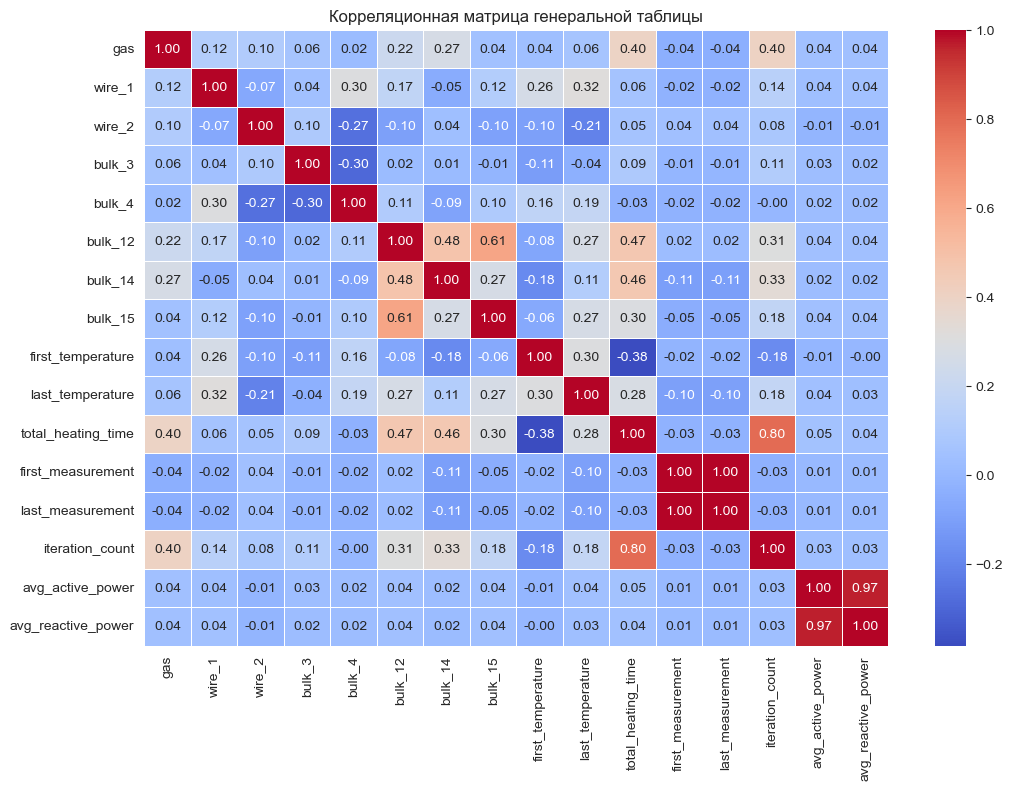

In [44]:
corr_matrix = merged_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 10})
plt.title('Корреляционная матрица генеральной таблицы')
plt.show()

**Промежуточный вывод:**
>_Анализ корреляционной матрицы показал наличие признаков с высокой степенью взаимосвязи,  
что может негативно сказаться на обобщающей способности моделей, особенно тех, которые  
используют линейное ядро. Для снижения мультиколлинеарности проведём трансформацию  
признаков. В частности, активная и реактивная мощность будут заменены на полную мощность,  
вычисляемую по ранее описанной формуле. Аналогично, время первого и последнего замера  
температуры, демонстрирующие наибольшую степень корреляции, будут объединены в  
единый признак — полное время.  
Кроме того, так как количество итераций коррелирует с общим временем нагрева,  
один из этих параметров необходимо исключить. Оптимальным выбором будет удаление  
признака с наименьшей дисперсией. Дополнительные пары высококоррелированных признаков,  
выявленные согласно таблице Чеддока, будут обработаны на этапе оптимизации,  
если качество моделей окажется неудовлетворительным._

In [45]:
merged_df['total_power'] = (merged_df['avg_active_power'] ** 2 + merged_df[
    'avg_reactive_power'] ** 2) ** 0.5

merged_df['full_time'] = (merged_df['last_measurement'] - merged_df[
    'first_measurement']).dt.total_seconds()

merged_df = merged_df.drop(
    columns=['avg_active_power', 'avg_reactive_power', 'first_measurement',
             'last_measurement', 'iteration_count'])

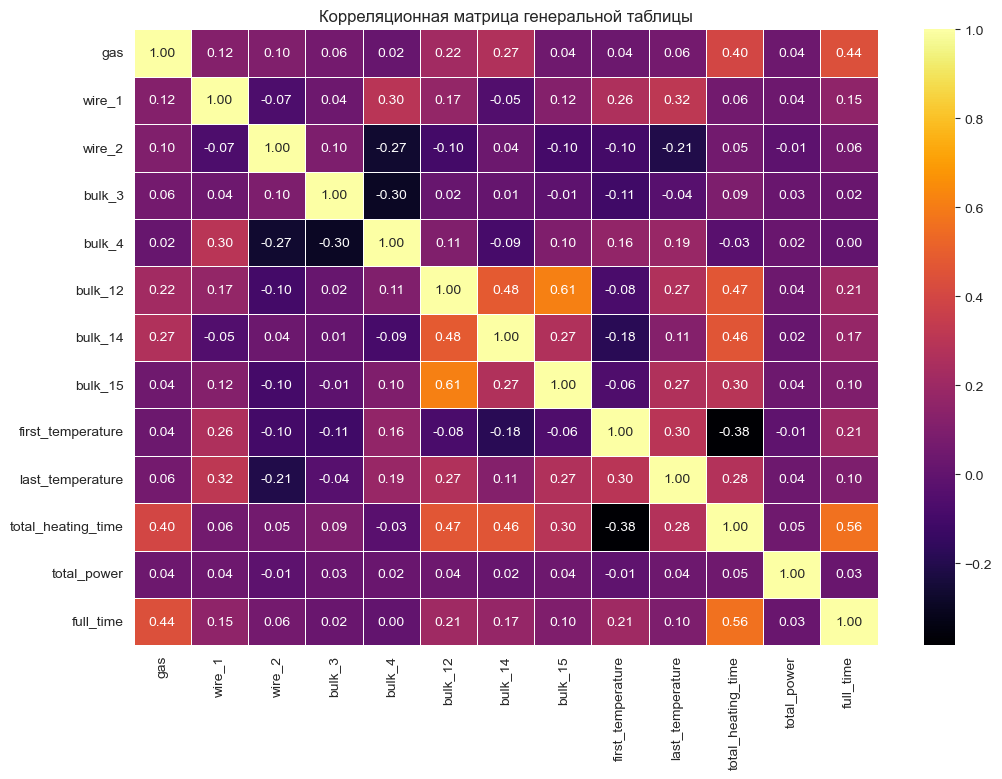

In [46]:
corr_matrix = merged_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="inferno",
            linewidths=0.5, annot_kws={"size": 10})
plt.title('Корреляционная матрица генеральной таблицы')
plt.show()

**Промежуточный вывод:**
>_Интересно, что некоторые сыпучие легирующие компоненты обладают выраженной  
отрицательной корреляцией, это связано с особенностями технического процесса  
выплавки разных марок стали, однако 15 и 12 добавки регулярно вносят в одну  
партию. Общее время нагрева находится в отрицательной корреляции с начальной  
температурой, здесь можно проследить причинно-следственную связь.  
Суммарный объём подаваемого газа тесно связан с временем выплавки партии,  
так происходит по причине того, что сплав продувают газом каждый раз, после  
добавления легирующих компонентов. Так же связь с временем выплавки  
обнаруживается bulk_12 и bulk_14, похоже внесение большого объёма этих добавок  
требуют марки стали, для которых характерна длительная варка._

## ➢ Обзор распределений

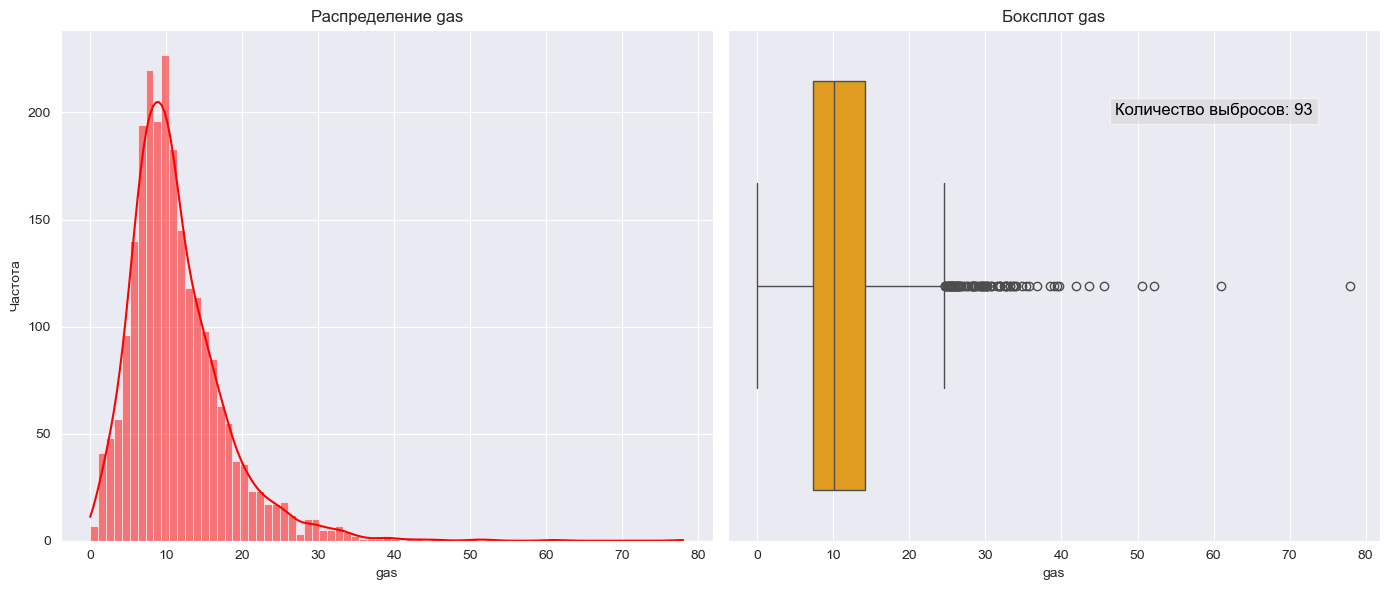

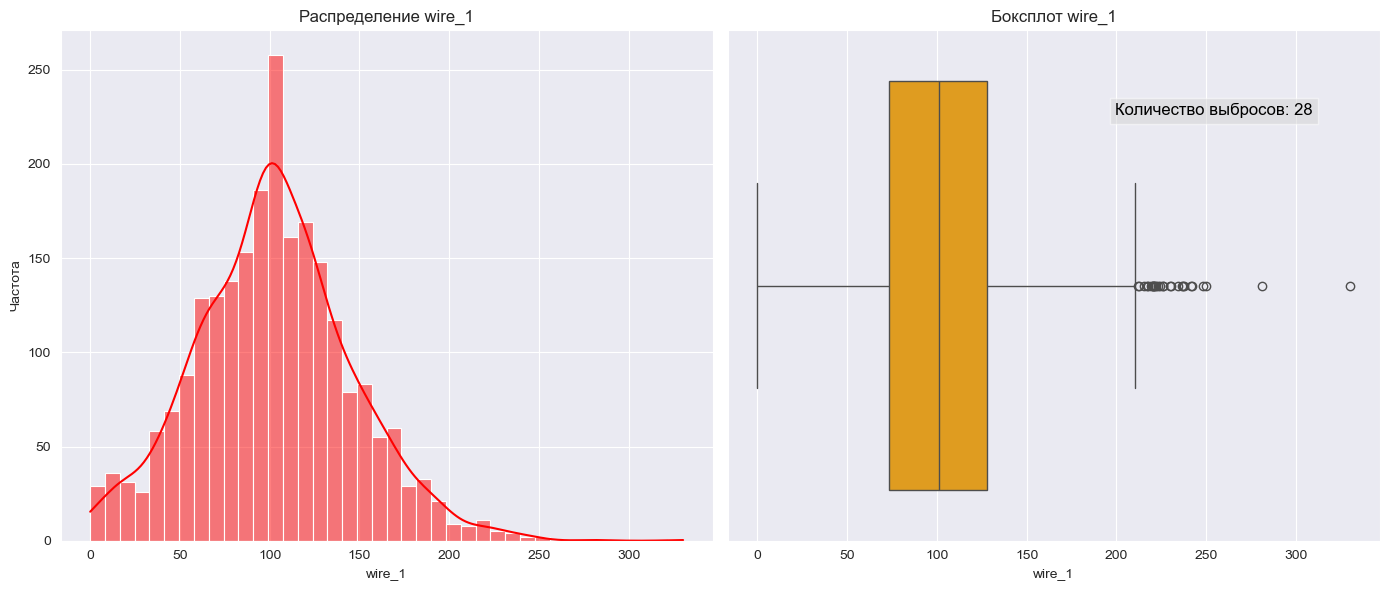

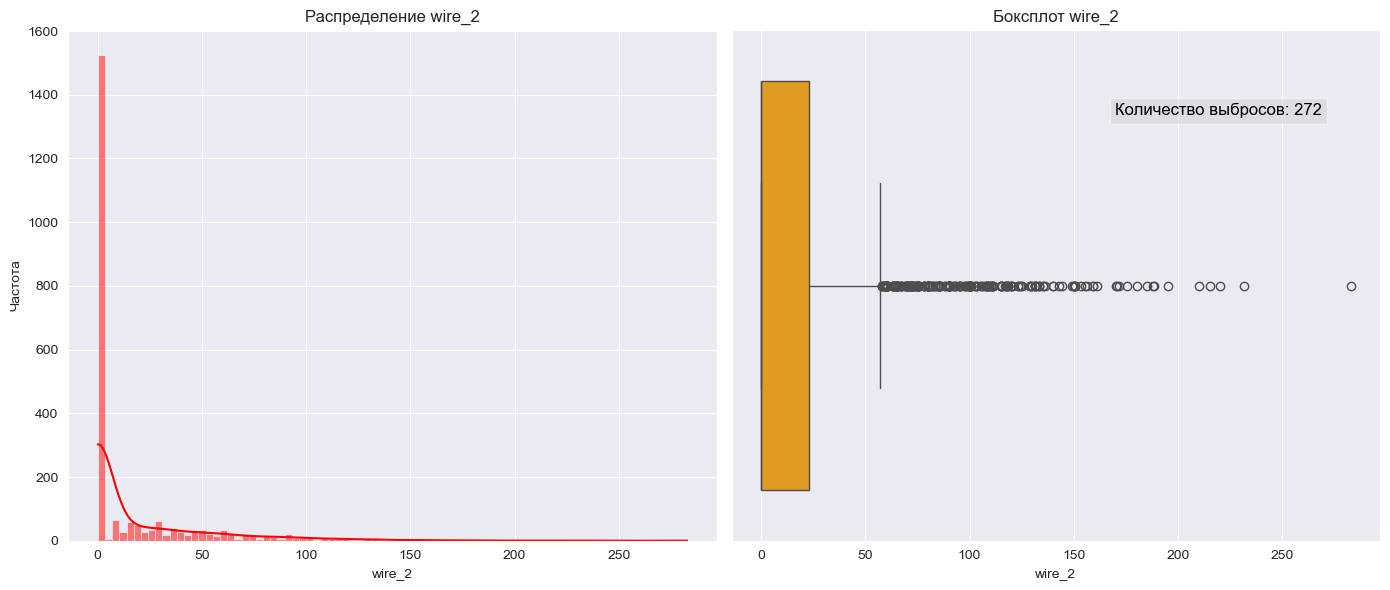

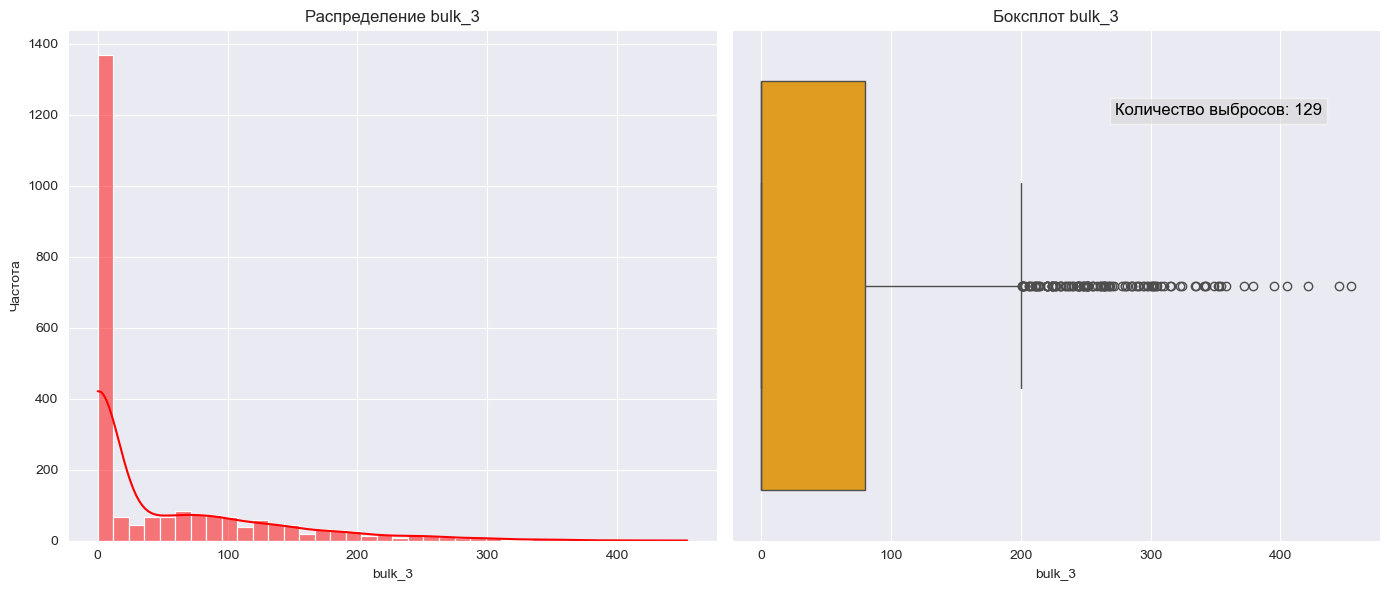

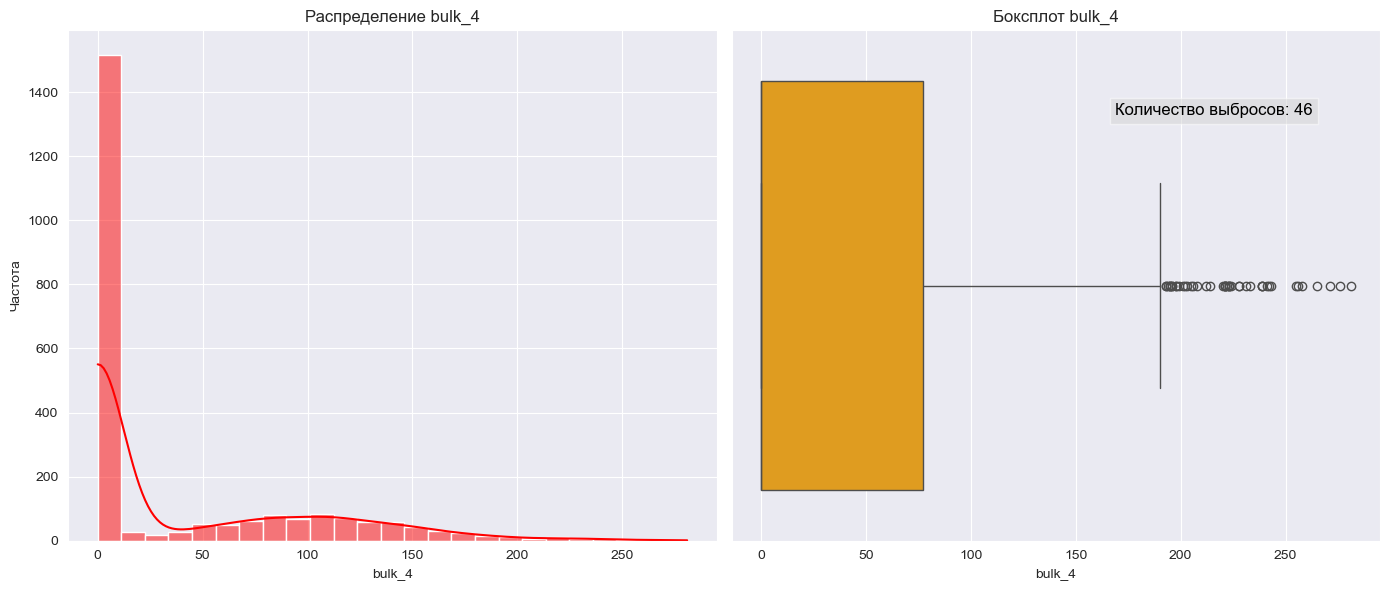

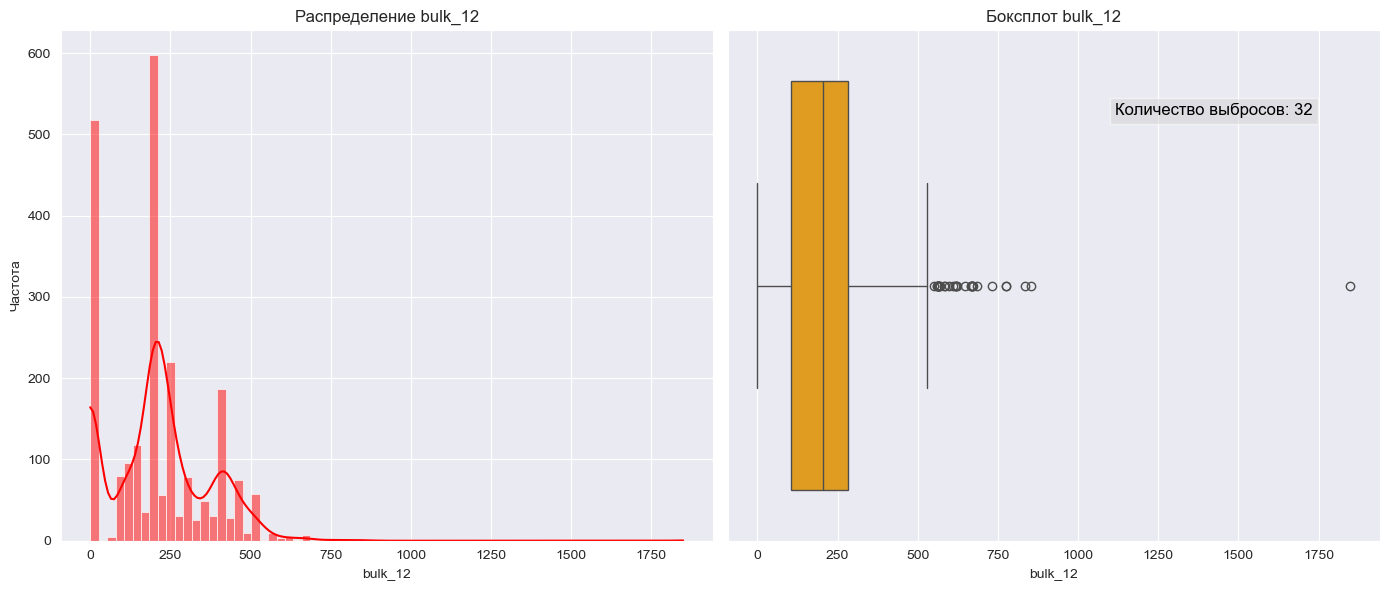

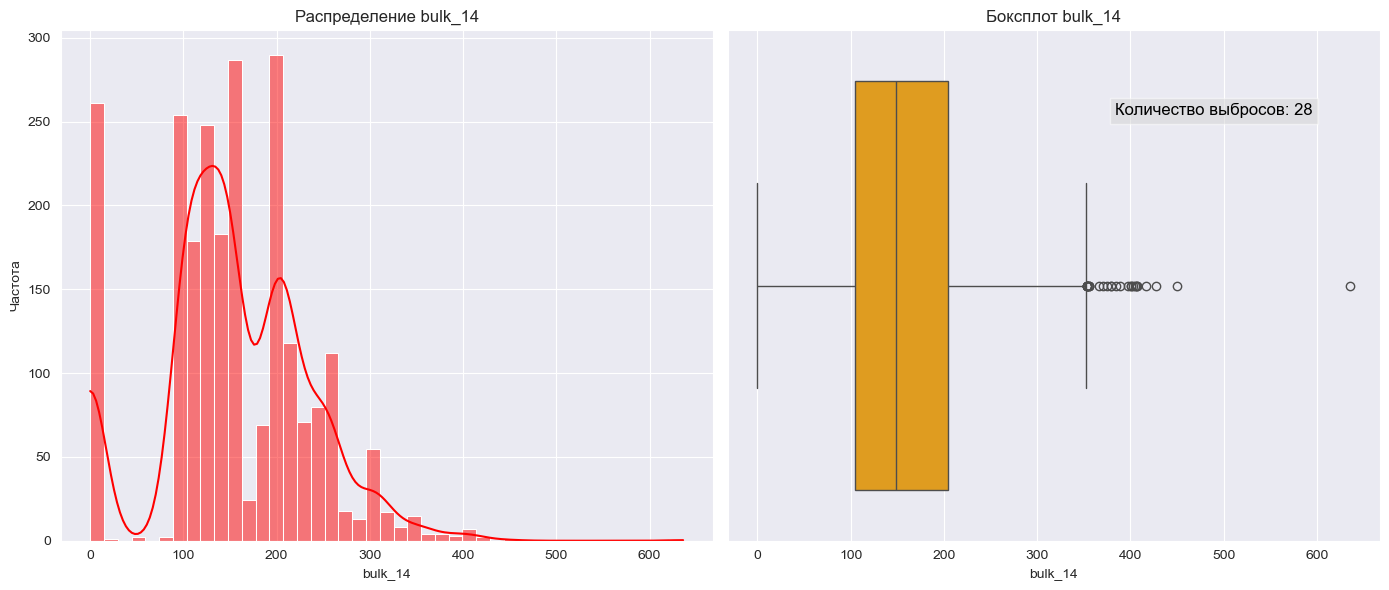

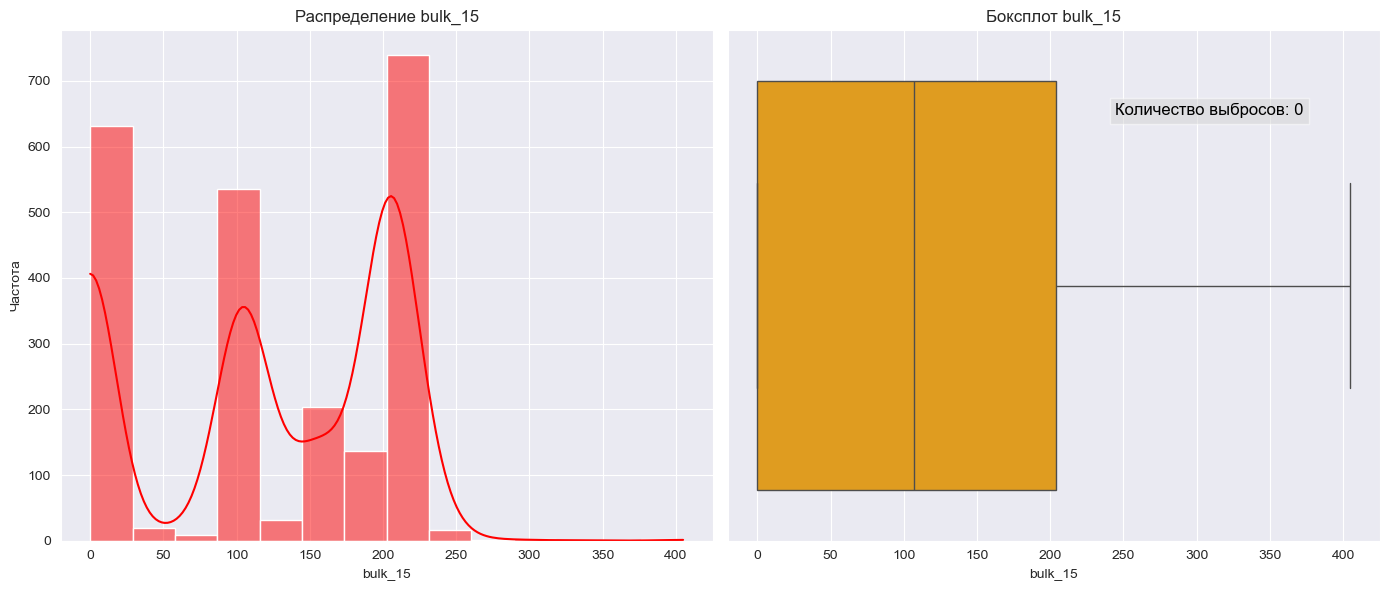

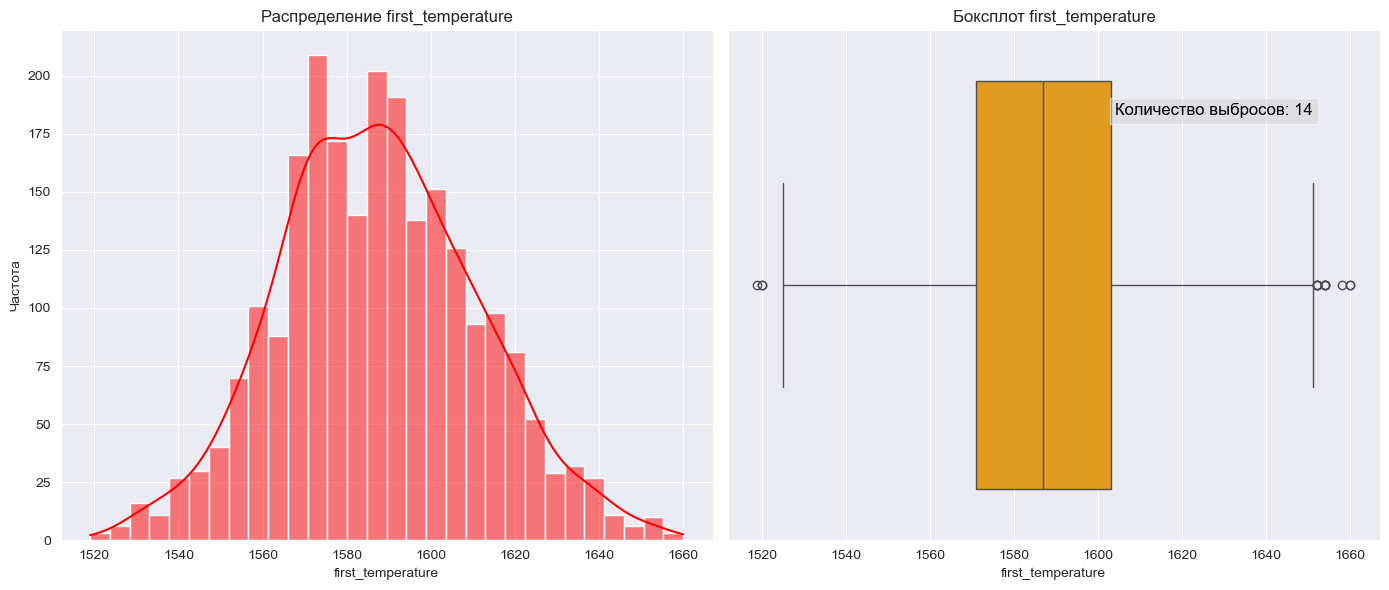

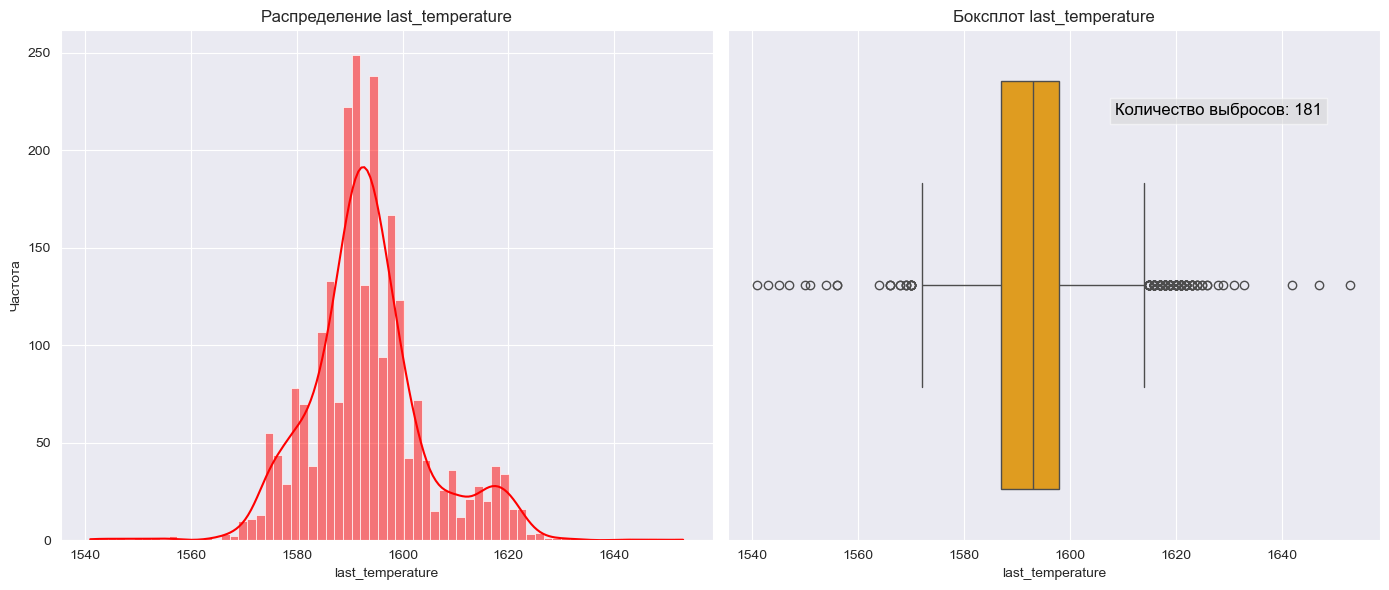

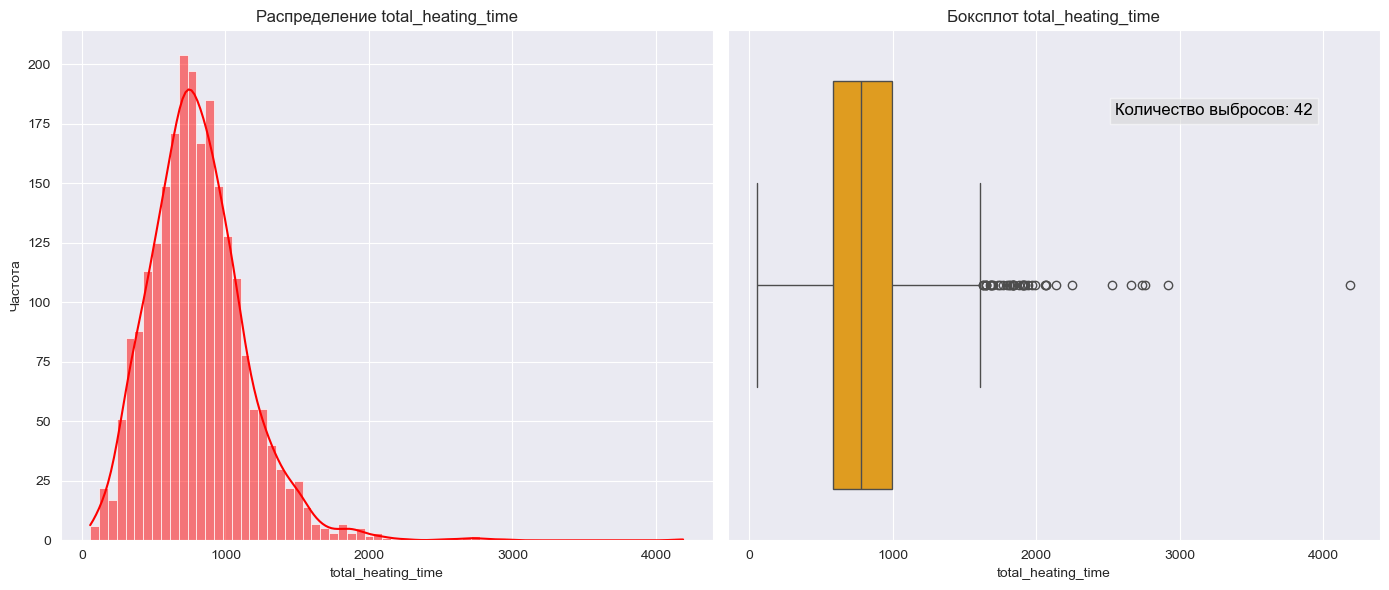

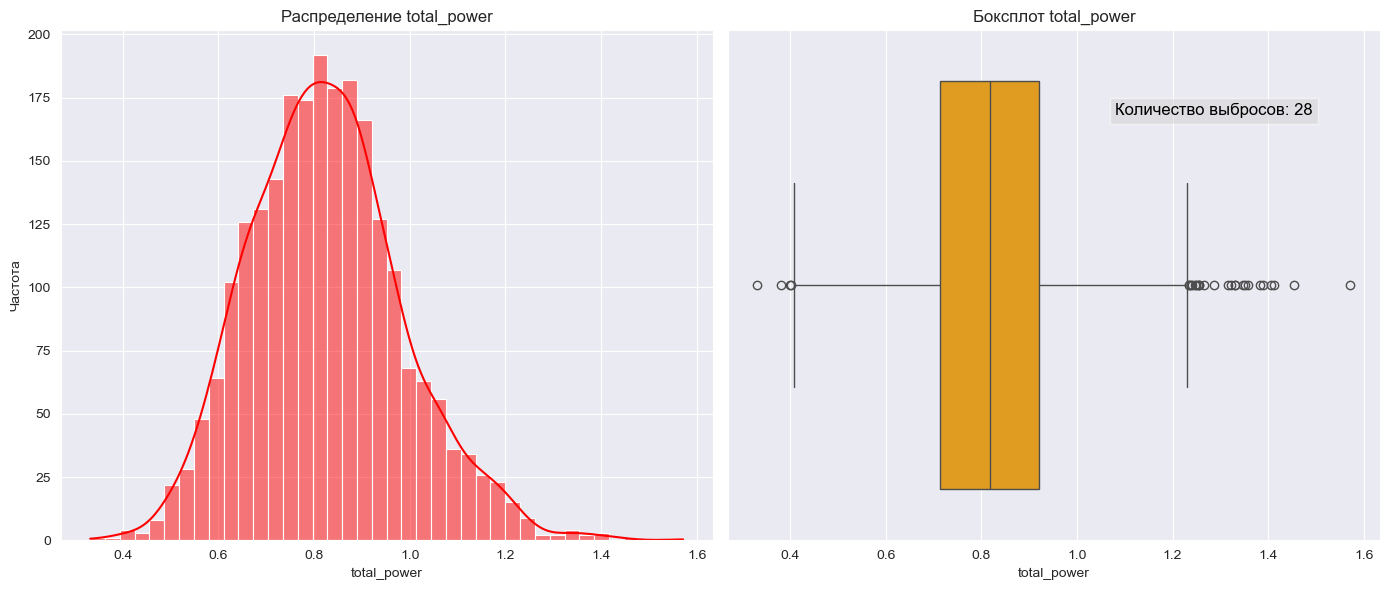

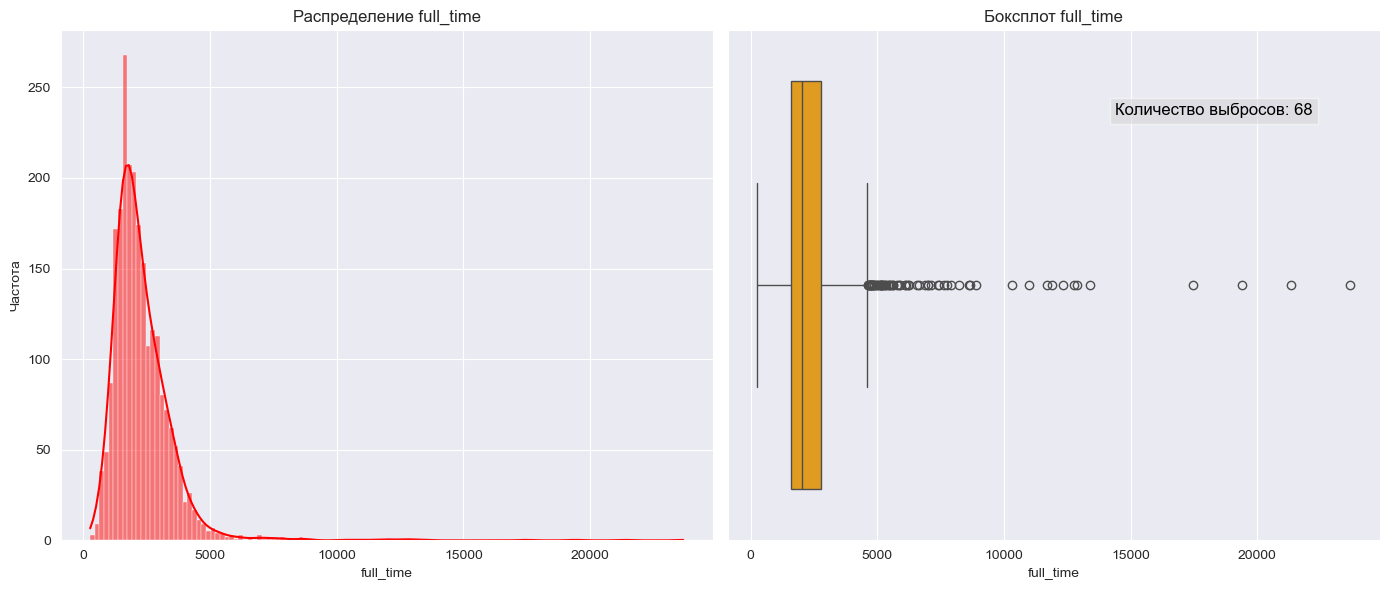

In [47]:
for column in merged_df.columns:
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(merged_df[column], kde=True, color='red')
    plt.title(f'Распределение {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')

    plt.subplot(1, 2, 2)
    boxplot = sns.boxplot(x=merged_df[column], color='orange')
    plt.title(f'Боксплот {column}')
    outliers = [line.get_xdata() for line in boxplot.get_lines() if
                line.get_linestyle() == 'None']
    outliers = [item for sublist in outliers for item in sublist]

    plt.figtext(0.8, 0.8, f'Количество выбросов: {len(outliers)}',
                fontsize=12,
                color='black', bbox=dict(facecolor='lightgrey', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Ⅴ Шаг. Подготовка данных 

In [48]:
const = 20924

In [49]:
X = merged_df[
    ['gas', 'wire_1', 'wire_2', 'bulk_3', 'bulk_4', 'bulk_12', 'bulk_14',
     'bulk_15', 'first_temperature', 'total_heating_time', 'total_power',
     'full_time']]

y = merged_df['last_temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=const)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

display(X_train_scaled_df.head(), X_test_scaled_df.head())
print(f"Размер тренировочной выборки: {X_train_scaled_df.shape[0]}",
      f"\nРазмер тестовой выборки: {X_test_scaled_df.shape[0]}")



,gas,wire_1,wire_2,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,first_temperature,total_heating_time,total_power,full_time
0,-0.125871,0.412115,1.673120,-0.641027,-0.630062,-1.307512,0.574405,-1.405555,-0.049016,-0.794928,-1.072563,-0.368143
1,-1.053275,1.028517,-0.044604,-0.641027,1.743082,-1.307512,-1.870948,-1.405555,1.905697,-1.498689,-0.862695,0.049242
2,-0.213328,0.378295,1.876273,2.370918,-0.630062,-1.307512,-1.870948,-1.405555,0.460909,-0.722525,0.242282,-0.485993
3,-0.717438,-1.686779,2.481195,-0.641027,-0.630062,0.304110,-0.544861,-0.145811,-0.516448,-0.505314,-0.060781,-0.612260
4,-0.490642,0.299744,-0.534346,-0.641027,1.048090,0.120827,-0.289376,1.231666,-0.941386,-0.047725,-1.940345,-0.742737


,gas,wire_1,wire_2,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,first_temperature,total_heating_time,total_power,full_time
0,-0.255941,0.178646,-0.075439,-0.103180,-0.630062,1.296363,1.000213,0.984427,0.418415,-0.983177,-0.552178,-1.035257
1,-0.726541,-1.150164,-0.534346,-0.641027,-0.630062,-0.018215,-0.690852,-0.145811,-0.983879,-0.212805,0.385698,-0.845154
2,-0.712410,-1.147982,0.971157,0.851499,-0.274090,0.323070,-0.398870,0.996200,-0.601435,-0.215701,-0.517822,-0.544216
3,0.343523,-0.206251,-0.534346,-0.641027,-0.630062,-0.643903,0.428414,-1.405555,1.055822,-0.566133,-0.532393,-0.095966
4,0.157867,-0.193377,-0.534346,0.932176,-0.630062,-0.005574,0.002606,0.442855,-0.983879,0.670517,-0.061620,-0.323949


Размер тренировочной выборки: 1746 
Размер тестовой выборки: 583


# Ⅵ Шаг. Обучение моделей машинного обучения

In [50]:
lin_reg = LinearRegression()

decision_tree = DecisionTreeRegressor()

ridge_reg = Ridge()

lasso_reg = Lasso()

In [51]:
param_grid_lin_reg = {
    'fit_intercept': [True, False]
}

param_grid_ridge = {
    'alpha': [0.1, 1, 10, 100, 1000],
    'fit_intercept': [True, False]
}

param_grid_lasso = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False]
}

param_grid_decision_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

## ➢ Оценка кросс-валидацией для линейной регрессии

In [52]:
grid_lin_reg = GridSearchCV(lin_reg, param_grid_lin_reg, cv=5,
                            scoring='neg_mean_absolute_error', verbose=2)

grid_lin_reg.fit(X_train_scaled, y_train)

print(
    f"MAE лучшей линейной регрессии на обучающей выборке: {-grid_lin_reg.best_score_:.4f}",
    f"\nЛучшие параметры: {grid_lin_reg.best_params_}")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END .................................fit_intercept=True; total time=   0.0s
[CV] END .................................fit_intercept=True; total time=   0.0s
[CV] END .................................fit_intercept=True; total time=   0.0s
[CV] END .................................fit_intercept=True; total time=   0.0s
[CV] END .................................fit_intercept=True; total time=   0.0s
[CV] END ................................fit_intercept=False; total time=   0.0s
[CV] END ................................fit_intercept=False; total time=   0.0s
[CV] END ................................fit_intercept=False; total time=   0.0s
[CV] END ................................fit_intercept=False; total time=   0.0s
[CV] END ................................fit_intercept=False; total time=   0.0s
MAE лучшей линейной регрессии на обучающей выборке: 6.1957 
Лучшие параметры: {'fit_intercept': True}


**Промежуточный вывод:**
>_По результатам кросс-валидации модель показала удовлетворительный результат.  
Значение **MAE** для лучшей модели **6.19**.  
Ожидаемо, что лучшей метрики удалось достичь для семейства моделей с  
включенным константным членом. Учтем наличие некоторой мультиколлинеарности  
в признаковом пространстве, и введем пенальти для функционала ошибок._

In [53]:
grid_ridge = GridSearchCV(ridge_reg, param_grid_ridge, cv=5,
                          scoring='neg_mean_absolute_error', verbose=2)

grid_ridge.fit(X_train_scaled, y_train)

print(
    f"MAE лучшей Ridge регрессии на обучающей выборке: {-grid_ridge.best_score_:.4f}",
    f"\nЛучшие параметры для Ridge: {grid_ridge.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END .....................alpha=0.1, fit_intercept=False; total time=   0.0s
[CV] END .....................alpha=0.1, fit_intercept=False; total time=   0.0s
[CV] END .....................alpha=0.1, fit_intercept=False; total time=   0.0s
[CV] END .....................alpha=0.1, fit_intercept=False; total time=   0.0s
[CV] END .....................alpha=0.1, fit_intercept=False; total time=   0.0s
[CV] END ........................alpha=1, fit_intercept=True; total time=   0.0s
[CV] END ........................alpha=1, fit_in

In [54]:
grid_lasso = GridSearchCV(lasso_reg, param_grid_lasso, cv=5,
                          scoring='neg_mean_absolute_error', verbose=2)

grid_lasso.fit(X_train_scaled, y_train)

print(
    f"MAE лучшей Lasso регрессии на обучающей выборке: {-grid_lasso.best_score_:.4f}",
    f"\nЛучшие параметры для Lasso: {grid_lasso.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END .....................alpha=0.01, fit_intercept=True; total time=   0.0s
[CV] END .....................alpha=0.01, fit_intercept=True; total time=   0.0s
[CV] END .....................alpha=0.01, fit_intercept=True; total time=   0.0s
[CV] END .....................alpha=0.01, fit_intercept=True; total time=   0.0s
[CV] END .....................alpha=0.01, fit_intercept=True; total time=   0.0s
[CV] END ....................alpha=0.01, fit_intercept=False; total time=   0.0s
[CV] END ....................alpha=0.01, fit_intercept=False; total time=   0.0s
[CV] END ....................alpha=0.01, fit_intercept=False; total time=   0.0s
[CV] END ....................alpha=0.01, fit_intercept=False; total time=   0.0s
[CV] END ....................alpha=0.01, fit_intercept=False; total time=   0.0s
[CV] END ......................alpha=0.1, fit_intercept=True; total time=   0.0s
[CV] END ......................alpha=0.1, fit_in

**Промежуточный вывод:**
>_Значение метрики улучшилось на тысячные доли, это говорит о том, что  
алгоритм не склонен завышать значения весовых коэффициентов.  
По итогам сравнения моделей линейной регрессии, лучший результат показала  
лассо-регрессия. Проведём для этого алгоритма анализ остатков._

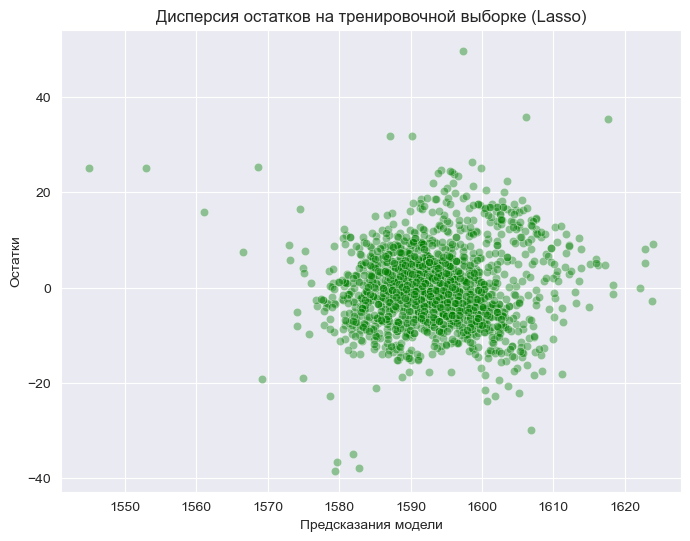

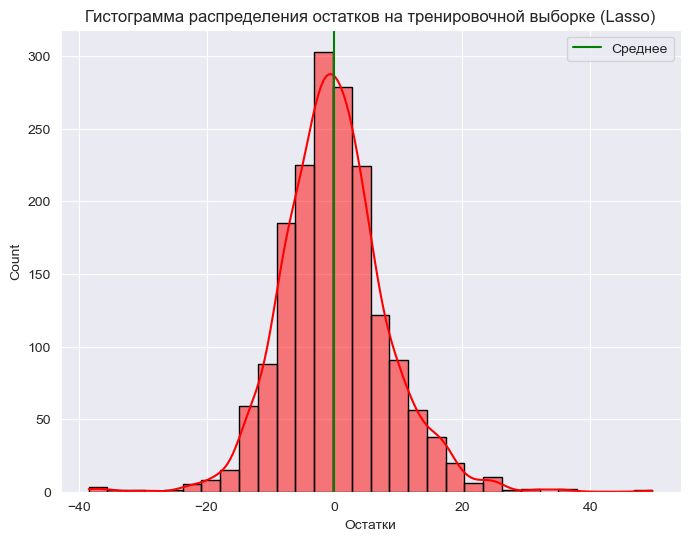

In [55]:
y_train_pred_lasso = grid_lasso.predict(X_train_scaled)

residuals_train = np.array(y_train).ravel() - y_train_pred_lasso

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_pred_lasso, y=residuals_train, color='green',
                alpha=0.4)
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Дисперсия остатков на тренировочной выборке (Lasso)')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(residuals_train, bins=30, color='red', edgecolor='black',
             kde=True)
plt.axvline(x=residuals_train.mean(), color='green', label='Среднее')
plt.title(
    'Гистограмма распределения остатков на тренировочной выборке (Lasso)')
plt.xlabel('Остатки')
plt.legend()
plt.show()

**Промежуточный вывод:**
>_На диаграмме рассеяния видно, что в распределении остатков отсутствует  
четкая закономерность, гистограмма показывает совпадение нуля и среднего  
значения для набора данных.  
Эти факторы свидетельствуют о том, что модель обладает высокой обобщающей  
способностью и не склонна к переобучению._

In [56]:
grid_decision_tree = GridSearchCV(decision_tree, param_grid_decision_tree,
                                  cv=5, scoring='neg_mean_absolute_error',
                                  verbose=2)

grid_decision_tree.fit(X_train_scaled, y_train)

print(
    f"MAE лучшего decision_tree регрессии на обучающей выборке: {-grid_decision_tree.best_score_:.4f}"
    f"\nЛучшие параметры для decision_tree: {grid_decision_tree.best_params_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=5, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=5; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=5; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=5; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=5; total time=   0.0s
[CV] END ...................max_depth=5, min_samples_split=5; total time=   0.0s
[CV] END ..................max_depth=5, min_samples_split=10; total time=   0.0s
[CV] END ..................max_depth=5, min_sampl

**Промежуточный вывод:**
>_DecisionTreeRegressor показал результат **MAE** в **7.41**, что не укладывается  
в требования заказчика._

In [57]:
results = {
    'Модель': ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree'],
    'MAE': [
        -grid_lin_reg.best_score_,
        -grid_ridge.best_score_,
        -grid_lasso.best_score_,
        -grid_decision_tree.best_score_
    ],
    'Лучший набор параметров': [
        grid_lin_reg.best_params_,
        grid_ridge.best_params_,
        grid_lasso.best_params_,
        grid_decision_tree.best_params_
    ]
}

results_df = pd.DataFrame(results)
results_df

,Модель,MAE,Лучший набор параметров
0,Linear Regression,6.195679,{'fit_intercept': True}
1,Ridge,6.190400,"{'alpha': 10, 'fit_intercept': True}"
2,Lasso,6.186900,"{'alpha': 0.1, 'fit_intercept': True}"
3,Decision Tree,7.396881,"{'max_depth': 5, 'min_samples_split': 2}"


# Ⅶ Шаг. Выбор лучшей модели 

In [58]:
y_test_pred_lasso = grid_lasso.predict(X_test_scaled)

mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"MAE лучшей модели Lasso на тестовой выборке: {mae_test_lasso:.4f}",
      f"\nR^2 лучшей модели Lasso на тестовой выборке: {r2_test_lasso:.4f}")

MAE лучшей модели Lasso на тестовой выборке: 5.9696 
R^2 лучшей модели Lasso на тестовой выборке: 0.4464


**Промежуточный вывод:**  
>_Получено значение коэффициента детерминации означает, что выбранная модель  
может объяснить примерно 44.64% вариации целевого признака._

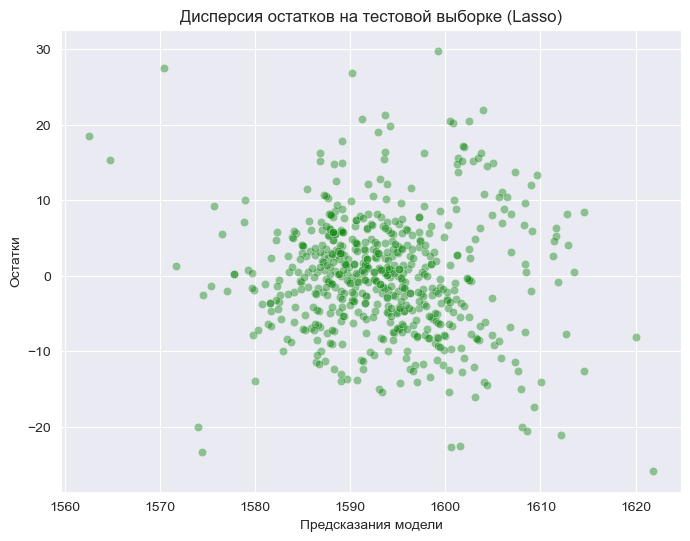

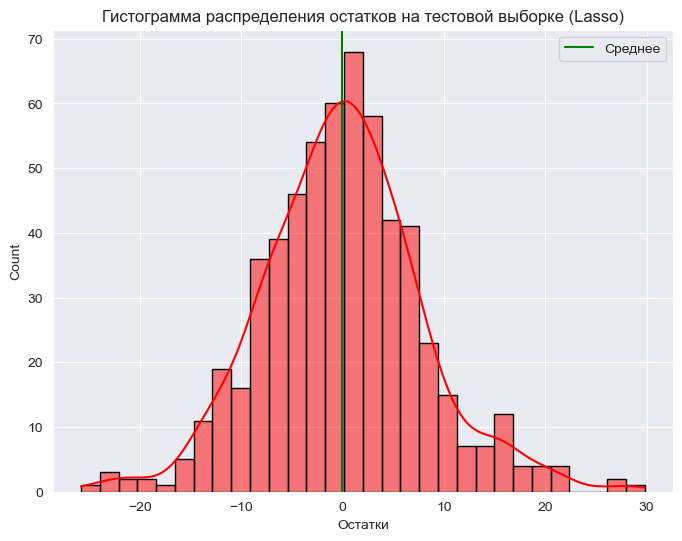

In [59]:
residuals_test = np.array(y_test).ravel() - y_test_pred_lasso

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_pred_lasso, y=residuals_test, color='green',
                alpha=0.4)
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Дисперсия остатков на тестовой выборке (Lasso)')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(residuals_test, bins=30, color='red', edgecolor='black', kde=True)
plt.axvline(x=residuals_test.mean(), color='green', label='Среднее')
plt.title('Гистограмма распределения остатков на тестовой выборке (Lasso)')
plt.xlabel('Остатки')
plt.legend()
plt.show()

**Промежуточный вывод:**
>_Метрика, демонстрируемая моделью на тестовом наборе данных полностью удовлетворяет  
требованиям заказчика. На графике рассеяния остатков не прослеживается  
закономерностей, среднее гистограммы совпадает с нулем._

## ➢ SHAP-анализ важности признаков

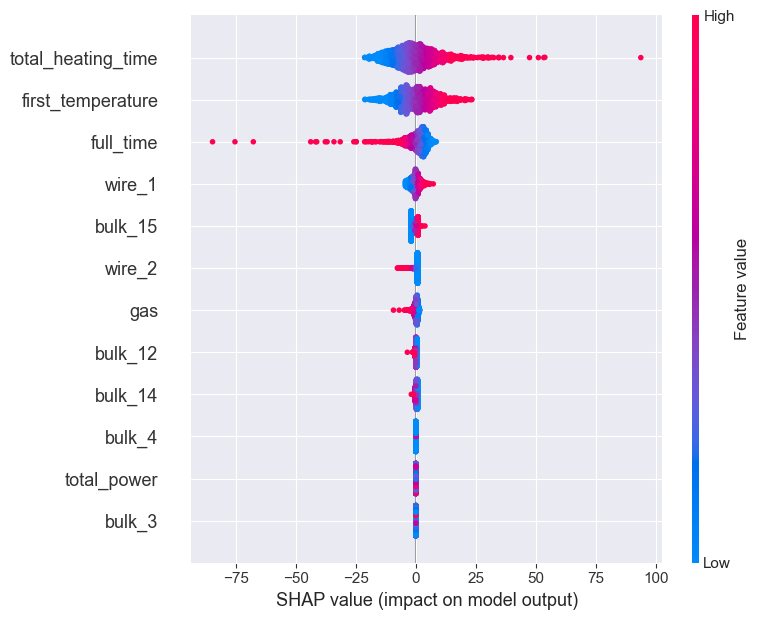

In [60]:
explainer = shap.Explainer(grid_lasso.best_estimator_, X_train_scaled)

shap_values = explainer(X_train_scaled)

shap.summary_plot(shap_values, X_train_scaled, feature_names=X_train.columns)

**Промежуточный вывод:**
>_Наиболее важным признаком оказалось общее время нагрева, ожидаемо, что  
высокие значения признака увеличивают итоговое предсказание, а низкие понижают.  
На втором месте оказалась температура первого замера, на этапе исследования  
объединенного датасета, она показывала выраженную корреляцию со временем нагрева.  
Полное время нагрева так же вносит свой стабильный вклад в значение целевого  
признака._

## ➢ Сравнение с константной моделью

In [61]:
dummy_regressor = DummyRegressor(strategy="mean")

dummy_regressor.fit(X_train_scaled, y_train)

y_test_pred_dummy = dummy_regressor.predict(X_test_scaled)

mae_test_dummy = mean_absolute_error(y_test, y_test_pred_dummy)
print(f"MAE дамми-регрессора на тестовой выборке: {mae_test_dummy:.4f}")
print(f"MAE модели Lasso на тестовой выборке: {mae_test_lasso:.4f}")

MAE дамми-регрессора на тестовой выборке: 7.7555
MAE модели Lasso на тестовой выборке: 5.9696


**Промежуточный вывод:**  
>_Выбранная модель показывает значения метрики, значительно превосходящие  
метрику дамми-модели._

# Ⅷ Шаг. Общий вывод и рекомендации заказчику

В рамках исследования для решения задачи прогнозирования были  
протестированы четыре модели машинного обучения:  
  
* Линейная регрессия  
* L1-регрессия (Lasso)  
* L2-регрессия (Ridge)  
* DecisionTreeRegressor  

Наилучший результат на тренировочной выборке показала Lasso-регрессия,  
что обусловлено её способностью к  автоматическому отбору наиболее  
значимых факторов и снижению влияния мультиколлинеарности.  
Данная модель была выбрана для финального этапа.  

На тестовой выборке средняя абсолютная ошибка (MAE) составила 5.96,  
что соответствует заданным критериям точности прогнозирования, определённым  
заказчиком. Оптимальная комбинация гиперпараметров: {'alpha': 0.1, 'fit_intercept': True}  
  
Анализ исходных данных выявил существенную долю пропущенных значений целевой переменной,  
что снижает информативность признакового пространства и ограничивает потенциал моделей машинного обучения.  
  
С точки зрения экономической эффективности, доработка алгоритма сбора данных позволит  
повысить вариативность признаков, что расширит возможности модели при обработке  
различных сценариев. Увеличить обобщающую способность алгоритмов, что приведёт к снижению  
ошибки и более точному прогнозированию температуры расплава, оптимизировать затраты на  
дальнейшие корректировки, так как качественные исходные данные минимизируют необходимость сложных постобработок. 
  
Реализация предложенных мер повысит стабильность и предсказательную способность системы, что в долгосрочной перспективе  
приведёт к улучшению производственных показателей и снижению затрат на контроль качества.